In [255]:
from pathlib import Path
import csv
import json
import math
import re
from collections import defaultdict

import pandas as pd
from IPython.display import display

# Change this to the folder that contains your copied sweep folders.
# Examples:
#   ROOTS = [Path("data_4seed")]
#   ROOTS = [Path("outputs")]
#   ROOTS = [Path("outputs/food101_l40s_8q8l2f_multiseed_28641701")]
#ROOTS = [Path("/Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/4_test/data_4seed")]
ROOTS = [Path("/Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/5_test/data_5seed_5")]

DATASET_FILTER = "food101"  # use "all" to keep every dataset found
OUT_DIR = Path("result_tables")
ROUND_DIGITS = 4


In [256]:
STAGE_TO_METHOD = {
    "linear_base": "Linear frozen-head baseline",
    "full_finetune": "Full fine-tune",
    "lora_dw": "LoRA depthwise adapter",
    "quad_dw": "Quadratic depthwise adapter",
    "scratch": "Scratch full training",
}

METHOD_ORDER = {
    "Linear frozen-head baseline": 0,
    "Quadratic depthwise adapter": 1,
    "LoRA depthwise adapter": 2,
    "Full fine-tune": 3,
    "Scratch full training": 4,
}

ADAPTER_RE = re.compile(
    r"^(?P<grid_id>\d+)_(?P<family>[ql])_(?P<scope>ls|all)_r(?P<rank>\d+)_"
    r"(?P<head>h[01])_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$"
)
FULL_RE = re.compile(r"^(?P<grid_id>\d+)_f_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$")
LINEAR_RE = re.compile(r"^(?P<grid_id>\d+)_lin_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$")
SEED_RE = re.compile(r"^seed_(?P<seed>\d+)$")
SWEEP_RE = re.compile(r"^food101_l40s_8q8l2f_multiseed_.+$")


def safe_float(value):
    """Return float(value), or None for empty / invalid values."""
    if value is None:
        return None
    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return None
        return float(value)
    text = str(value).strip()
    if not text or text.lower() in {"none", "nan", "na", "n/a"}:
        return None
    try:
        return float(text)
    except ValueError:
        return None


def decode_num_token(token, *, kind="generic"):
    """Decode run-name tokens such as 1em3 -> 1e-3, 0p05 -> 0.05, 3e5 -> 3e-5."""
    if token is None:
        return None
    text = str(token).strip()
    if not text or text.lower() in {"none", "full"}:
        return None

    text = text.replace("p", ".")
    text = text.replace("em", "e-")

    # Full fine-tune run names were written as lr1e4/lr3e5, but the manifest
    # uses 1e-4/3e-5. Treat bare positive exponent LR tokens as compact negative exponents.
    if kind == "lr" and re.fullmatch(r"\d+(?:\.\d+)?e\d+", text):
        mantissa, exponent = text.split("e", 1)
        text = f"{mantissa}e-{exponent}"

    return safe_float(text)


def infer_sweep_name(path):
    for part in path.parts:
        if SWEEP_RE.match(part):
            return part
    for i, part in enumerate(path.parts):
        if SEED_RE.match(part) and i > 0:
            return path.parts[i - 1]
    return "unknown_sweep"


def infer_seed_from_path(path):
    for part in path.parts:
        m = SEED_RE.match(part)
        if m:
            return m.group("seed")
    return None


def infer_seed_from_metrics(metrics):
    base = metrics.get("base_checkpoint")
    if base:
        m = re.search(r"(?:^|/)seed_(\d+)(?:/|$)", str(base))
        if m:
            return m.group(1)
    return None


def infer_run_name(path):
    parts = path.parts
    for i, part in enumerate(parts):
        if SEED_RE.match(part) and i + 1 < len(parts):
            return parts[i + 1]
    return None


def parse_run_name(run_name):
    """Infer stage/scope/rank/head/lr/wd from the run folder name."""
    info = {
        "grid_id": None,
        "family": None,
        "scope_from_name": None,
        "rank_from_name": None,
        "train_head_from_name": None,
        "lr_from_name": None,
        "weight_decay_from_name": None,
    }
    if not run_name:
        return info

    m = ADAPTER_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "quad_dw" if g["family"] == "q" else "lora_dw",
            "scope_from_name": "last_stage" if g["scope"] == "ls" else "all",
            "rank_from_name": int(g["rank"]),
            "train_head_from_name": "yes" if g["head"] == "h1" else "no",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    m = FULL_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "full_finetune",
            "scope_from_name": "all",
            "rank_from_name": "full",
            "train_head_from_name": "full",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    m = LINEAR_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "linear_base",
            "scope_from_name": "none",
            "rank_from_name": "none",
            "train_head_from_name": "head_only",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    return info


In [257]:
def read_manifest(path):
    """Read one manifest.tsv produced by the sweep script."""
    rows = []
    sweep_name = infer_sweep_name(path)
    with path.open("r", newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for raw in reader:
            if not raw or not raw.get("run_name"):
                continue
            row = {
                "seed": str(raw.get("seed", "")).strip(),
                "run_name": str(raw.get("run_name", "")).strip(),
                "stage": str(raw.get("stage", "")).strip(),
                "scope": str(raw.get("scope", "")).strip(),
                "rank": str(raw.get("rank", "")).strip(),
                "train_head": str(raw.get("train_head", "")).strip(),
                "lr": str(raw.get("lr", "")).strip(),
                "weight_decay": str(raw.get("weight_decay", "")).strip(),
                "output_dir": str(raw.get("output_dir", "")).strip(),
                "manifest_path": str(path),
                "sweep_name": sweep_name,
            }
            rows.append(row)
    return rows


def load_manifests(roots):
    manifest_rows = []
    for root in roots:
        root = Path(root).expanduser()
        if root.exists():
            manifest_rows.extend(row for p in root.rglob("manifest.tsv") for row in read_manifest(p))

    by_sweep_seed_run = {}
    by_seed_run = {}
    for row in manifest_rows:
        by_sweep_seed_run[(row["sweep_name"], row["seed"], row["run_name"])] = row
        by_seed_run[(row["seed"], row["run_name"])] = row
    return manifest_rows, by_sweep_seed_run, by_seed_run


def find_metrics_files(roots):
    """Find every metrics.json under each root."""
    files = []
    seen = set()
    for root in roots:
        root = Path(root).expanduser()
        if not root.exists():
            print(f"[warning] root does not exist: {root}")
            continue
        candidates = [root] if root.is_file() and root.name == "metrics.json" else list(root.rglob("metrics.json"))
        for path in candidates:
            resolved = path.resolve()
            if resolved not in seen:
                files.append(path)
                seen.add(resolved)
    return sorted(files)


def read_json(path):
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"{path} is not a JSON object")
    return data


def get_metric_array(metrics, key):
    value = metrics.get(key, [])
    if not isinstance(value, list):
        return []
    out = []
    for item in value:
        number = safe_float(item)
        if number is not None:
            out.append(number)
    return out


def last_or_none(values):
    return values[-1] if values else None


def best_max(values):
    if not values:
        return None, None
    idx, value = max(enumerate(values), key=lambda item: item[1])
    return value, idx + 1


def best_min(values):
    if not values:
        return None, None
    idx, value = min(enumerate(values), key=lambda item: item[1])
    return value, idx + 1


In [258]:
def build_run_row(metrics_path, metrics, by_sweep_seed_run, by_seed_run):
    sweep_name = infer_sweep_name(metrics_path)
    seed = infer_seed_from_path(metrics_path) or infer_seed_from_metrics(metrics) or "unknown"
    run_name = infer_run_name(metrics_path) or "unknown_run"
    parsed = parse_run_name(run_name)

    manifest = by_sweep_seed_run.get((sweep_name, seed, run_name)) or by_seed_run.get((seed, run_name))

    stage = str(metrics.get("stage") or (manifest["stage"] if manifest else "") or parsed.get("family") or "unknown")
    dataset = str(metrics.get("dataset") or "unknown")
    method = STAGE_TO_METHOD.get(stage, stage)

    scope = manifest["scope"] if manifest else None
    rank = manifest["rank"] if manifest else None
    train_head = manifest["train_head"] if manifest else None
    lr = safe_float(manifest["lr"]) if manifest else None
    weight_decay = safe_float(manifest["weight_decay"]) if manifest else None

    scope = scope or parsed.get("scope_from_name")
    rank = rank if rank not in (None, "") else parsed.get("rank_from_name")
    train_head = train_head or parsed.get("train_head_from_name")
    lr = lr if lr is not None else parsed.get("lr_from_name")
    weight_decay = weight_decay if weight_decay is not None else parsed.get("weight_decay_from_name")

    # For adapter runs, the parent folder also contains scope/rank, e.g. last_stage_rank_4.
    if stage in {"lora_dw", "quad_dw"}:
        m = re.match(r"(?P<scope>last_stage|all)_rank_(?P<rank>\d+)$", metrics_path.parent.name)
        if m:
            scope = scope or m.group("scope")
            rank = rank or int(m.group("rank"))

    train_loss = get_metric_array(metrics, "train_loss")
    train_acc = get_metric_array(metrics, "train_acc")
    test_loss = get_metric_array(metrics, "test_loss")
    test_acc = get_metric_array(metrics, "test_acc")

    best_test_acc, best_test_acc_epoch = best_max(test_acc)
    best_test_loss, best_test_loss_epoch = best_min(test_loss)
    best_train_acc, best_train_acc_epoch = best_max(train_acc)

    final_test_acc = last_or_none(test_acc)
    final_train_acc = last_or_none(train_acc)
    final_test_loss = last_or_none(test_loss)
    final_train_loss = last_or_none(train_loss)

    training_time_sec = safe_float(metrics.get("training_time_sec"))
    trainable_params = safe_float(metrics.get("trainable_params"))
    total_params = safe_float(metrics.get("total_params"))
    trainable_pct = 100.0 * trainable_params / total_params if trainable_params is not None and total_params else None

    return {
        "sweep": sweep_name,
        "seed": seed,
        "dataset": dataset,
        "run_name": run_name,
        "grid_id": parsed.get("grid_id"),
        "method": method,
        "stage": stage,
        "scope": scope,
        "rank": rank,
        "train_head": train_head,
        "lr": lr,
        "weight_decay": weight_decay,
        "epochs_completed": max(len(train_loss), len(train_acc), len(test_loss), len(test_acc)),
        "final_train_loss": final_train_loss,
        "final_train_acc": final_train_acc,
        "final_test_loss": final_test_loss,
        "final_test_acc": final_test_acc,
        "best_train_acc": best_train_acc,
        "best_train_acc_epoch": best_train_acc_epoch,
        "best_test_acc": best_test_acc,
        "best_test_acc_epoch": best_test_acc_epoch,
        "best_test_loss": best_test_loss,
        "best_test_loss_epoch": best_test_loss_epoch,
        "best_minus_final_test_acc": (best_test_acc - final_test_acc) if best_test_acc is not None and final_test_acc is not None else None,
        "final_generalization_gap": (final_train_acc - final_test_acc) if final_train_acc is not None and final_test_acc is not None else None,
        "trainable_params": int(trainable_params) if trainable_params is not None else None,
        "total_params": int(total_params) if total_params is not None else None,
        "trainable_pct": trainable_pct,
        "training_time_sec": training_time_sec,
        "training_time_min": training_time_sec / 60.0 if training_time_sec is not None else None,
        "training_time_hr": training_time_sec / 3600.0 if training_time_sec is not None else None,
        "base_checkpoint": metrics.get("base_checkpoint"),
        "metrics_path": str(metrics_path),
    }


def build_epoch_rows(run_row, metrics):
    train_loss = get_metric_array(metrics, "train_loss")
    train_acc = get_metric_array(metrics, "train_acc")
    test_loss = get_metric_array(metrics, "test_loss")
    test_acc = get_metric_array(metrics, "test_acc")
    n = max(len(train_loss), len(train_acc), len(test_loss), len(test_acc))
    rows = []
    for i in range(n):
        rows.append({
            "sweep": run_row["sweep"],
            "seed": run_row["seed"],
            "dataset": run_row["dataset"],
            "run_name": run_row["run_name"],
            "grid_id": run_row.get("grid_id"),   # <-- add this line
            "method": run_row["method"],
            "stage": run_row["stage"],
            "scope": run_row["scope"],
            "rank": run_row["rank"],
            "train_head": run_row["train_head"],
            "lr": run_row["lr"],
            "weight_decay": run_row["weight_decay"],
            "epoch": i + 1,
            "train_loss": train_loss[i] if i < len(train_loss) else None,
            "train_acc": train_acc[i] if i < len(train_acc) else None,
            "test_loss": test_loss[i] if i < len(test_loss) else None,
            "test_acc": test_acc[i] if i < len(test_acc) else None,
            "metrics_path": run_row["metrics_path"],
        })
    return rows


In [259]:
def sort_run_dataframe(df):
    if df.empty:
        return df
    out = df.copy()
    out["_seed_sort"] = pd.to_numeric(out["seed"], errors="coerce").fillna(999999)
    out["_method_sort"] = out["method"].map(METHOD_ORDER).fillna(99)
    out["_grid_sort"] = pd.to_numeric(out["grid_id"], errors="coerce").fillna(999999)
    out = out.sort_values(["_seed_sort", "_method_sort", "_grid_sort", "run_name"]).drop(columns=["_seed_sort", "_method_sort", "_grid_sort"])
    return out.reset_index(drop=True)


def summarize_by_config(all_runs):
    if all_runs.empty:
        return pd.DataFrame()

    group_cols = ["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"]
    df = all_runs.copy()
    df["rank"] = df["rank"].astype(str)
    df["scope"] = df["scope"].astype(str)
    df["train_head"] = df["train_head"].astype(str)

    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(
            n_seeds=("seed", "nunique"),
            seeds=("seed", lambda x: ",".join(sorted(set(map(str, x)), key=lambda s: int(s) if s.isdigit() else 999999))),
            best_test_acc_mean=("best_test_acc", "mean"),
            best_test_acc_std=("best_test_acc", "std"),
            final_test_acc_mean=("final_test_acc", "mean"),
            final_test_acc_std=("final_test_acc", "std"),
            best_test_loss_mean=("best_test_loss", "mean"),
            final_test_loss_mean=("final_test_loss", "mean"),
            training_time_hr_mean=("training_time_hr", "mean"),
            trainable_params_mean=("trainable_params", "mean"),
            trainable_pct_mean=("trainable_pct", "mean"),
            run_names=("run_name", lambda x: ",".join(sorted(set(map(str, x))))),
        )
        .reset_index()
    )
    summary["best_test_acc_std"] = summary["best_test_acc_std"].fillna(0.0)
    summary["final_test_acc_std"] = summary["final_test_acc_std"].fillna(0.0)
    summary["_method_sort"] = summary["method"].map(METHOD_ORDER).fillna(99)
    summary = summary.sort_values(["_method_sort", "best_test_acc_mean"], ascending=[True, False]).drop(columns="_method_sort")
    return summary.reset_index(drop=True)


def summarize_best_by_method(summary_by_config):
    if summary_by_config.empty:
        return pd.DataFrame()
    idx = summary_by_config.groupby("method")["best_test_acc_mean"].idxmax()
    out = summary_by_config.loc[idx].sort_values("best_test_acc_mean", ascending=False)
    return out.reset_index(drop=True)


def expected_grid():
    """Fallback expected grid from the sweep scripts: 1 linear, 8 quadratic, 8 LoRA, 2 full fine-tune runs."""
    specs = [{
        "run_name": "000_lin_lr1e3_wd0p05", "stage": "linear_base", "scope": "none", "rank": "none",
        "train_head": "head_only", "lr": 1e-3, "weight_decay": 0.05,
    }]
    adapter_specs = [
        ("last_stage", 1, "no", 1e-3, 0.0),
        ("last_stage", 2, "no", 1e-3, 0.0),
        ("last_stage", 4, "no", 1e-3, 0.0),
        ("last_stage", 2, "no", 3e-4, 0.01),
        ("all", 1, "no", 3e-4, 0.0),
        ("all", 2, "no", 3e-4, 0.0),
        ("last_stage", 2, "yes", 1e-4, 0.0),
        ("all", 2, "yes", 1e-4, 0.0),
    ]
    for offset, stage, prefix in [(100, "quad_dw", "q"), (200, "lora_dw", "l")]:
        for idx, (scope, rank, head, lr, wd) in enumerate(adapter_specs, start=1):
            scope_tag = "ls" if scope == "last_stage" else "all"
            htag = "h1" if head == "yes" else "h0"
            lr_token = str(lr).replace("e-", "em").replace(".", "p")
            wd_token = str(wd).replace(".", "p")
            specs.append({
                "run_name": f"{offset + idx:03d}_{prefix}_{scope_tag}_r{rank}_{htag}_lr{lr_token}_wd{wd_token}",
                "stage": stage, "scope": scope, "rank": str(rank), "train_head": head, "lr": lr, "weight_decay": wd,
            })
    specs.extend([
        {"run_name": "301_f_lr1e4_wd0p01", "stage": "full_finetune", "scope": "all", "rank": "full", "train_head": "full", "lr": 1e-4, "weight_decay": 0.01},
        {"run_name": "302_f_lr3e5_wd0p05", "stage": "full_finetune", "scope": "all", "rank": "full", "train_head": "full", "lr": 3e-5, "weight_decay": 0.05},
    ])
    return pd.DataFrame(specs)


def missing_expected_runs(all_runs, manifest_rows):
    if all_runs.empty:
        return pd.DataFrame()

    seeds = sorted(all_runs.loc[all_runs["seed"] != "unknown", "seed"].astype(str).unique(), key=lambda x: int(x) if x.isdigit() else 999999)
    present = set(zip(all_runs["seed"].astype(str), all_runs["run_name"].astype(str)))

    expected_by_seed = defaultdict(list)
    for m in manifest_rows:
        expected_by_seed[m["seed"]].append({
            "run_name": m["run_name"], "stage": m["stage"], "scope": m["scope"], "rank": m["rank"],
            "train_head": m["train_head"], "lr": safe_float(m["lr"]), "weight_decay": safe_float(m["weight_decay"]),
        })

    fallback = expected_grid().to_dict("records")
    missing = []
    for seed in seeds:
        specs = expected_by_seed.get(seed) or fallback
        for spec in specs:
            if (seed, spec["run_name"]) not in present:
                missing.append({"seed": seed, **spec})
    return pd.DataFrame(missing)


In [260]:
def collect_experiments(roots=ROOTS, dataset_filter=DATASET_FILTER):
    roots = [Path(p).expanduser() for p in roots]
    manifest_rows, by_sweep_seed_run, by_seed_run = load_manifests(roots)
    metrics_files = find_metrics_files(roots)

    run_rows = []
    epoch_rows = []
    skipped = []

    for metrics_path in metrics_files:
        try:
            metrics = read_json(metrics_path)
        except Exception as exc:
            skipped.append((str(metrics_path), str(exc)))
            continue

        dataset = str(metrics.get("dataset") or "unknown")
        if dataset_filter.lower() != "all" and dataset.lower() != dataset_filter.lower():
            continue

        row = build_run_row(metrics_path, metrics, by_sweep_seed_run, by_seed_run)
        run_rows.append(row)
        epoch_rows.extend(build_epoch_rows(row, metrics))

    all_runs = sort_run_dataframe(pd.DataFrame(run_rows))
    epoch_history = sort_run_dataframe(pd.DataFrame(epoch_rows)) if epoch_rows else pd.DataFrame()
    summary_config = summarize_by_config(all_runs)
    summary_method = summarize_best_by_method(summary_config)
    missing = missing_expected_runs(all_runs, manifest_rows)

    print("Loaded metrics files:", len(metrics_files))
    print("Runs kept after dataset filter:", len(all_runs))
    print("Manifests found rows:", len(manifest_rows))
    if skipped:
        print("Skipped invalid metrics files:", len(skipped))
        display(pd.DataFrame(skipped, columns=["path", "reason"]))

    return all_runs, epoch_history, summary_config, summary_method, missing


all_runs, epoch_history, summary_by_config, summary_by_method, missing_expected = collect_experiments()


Loaded metrics files: 74
Runs kept after dataset filter: 74
Manifests found rows: 74


In [261]:
# Main one-row-per-run table
view_cols = [
    "seed", "run_name", "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay",
    "epochs_completed", "best_test_acc", "best_test_acc_epoch", "final_test_acc",
    "trainable_params", "trainable_pct", "training_time_hr",
]

display(all_runs[view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc": "{:.4f}",
    "final_test_acc": "{:.4f}",
    "trainable_pct": "{:.2f}",
    "training_time_hr": "{:.2f}",
}))


,seed,run_name,method,stage,scope,rank,train_head,lr,weight_decay,epochs_completed,best_test_acc,best_test_acc_epoch,final_test_acc,trainable_params,trainable_pct,training_time_hr
0,21,000_lin_lr1e3_wd0p05,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,30,0.7881,12,0.7841,77669,0.28,1.22
1,21,000_lin_lr1e3_wd0p05,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,30,0.7881,12,0.7841,77669,0.28,1.42
2,21,109_q_all_r2_h1_lr1em4_wd0p0_k3d3,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,16,0.8029,16,0.8029,316133,1.12,1.31
3,21,110_q_all_r2_h1_lr3em4_wd0p0_k3d3,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-04,0,16,0.8076,12,0.8074,316133,1.12,1.31
4,21,111_q_all_r2_h1_lr3em5_wd0p0_k3d3,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-05,0,16,0.8000,15,0.8000,316133,1.12,1.31
5,21,112_q_all_r1_h1_lr1em4_wd0p0_k3d3,Quadratic depthwise adapter,quad_dw,all,1,yes,1.0e-04,0,16,0.8034,16,0.8034,196901,0.70,0.91
6,21,113_q_all_r2_h1_lr1em4_wd0p05_k3d3,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0.05,16,0.8035,15,0.8030,316133,1.12,1.31
7,21,114_q_all_r2_h1_lr1em4_wd0p0_k3d3_a0p5,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,16,0.8025,13,0.8019,316133,1.12,1.33
8,21,115_q_all_r2_h1_lr1em4_wd0p0_k3d3_a2p0,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,16,0.8048,16,0.8048,316133,1.12,1.31
9,21,116_q_ls_r2_h1_lr1em4_wd0p0_k3d3,Quadratic depthwise adapter,quad_dw,last_stage,2,yes,1.0e-04,0,16,0.7931,9,0.7925,160613,0.57,0.65


In [262]:
# Summary across seeds for every hyperparameter configuration
summary_view_cols = [
    "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay", "n_seeds", "seeds",
    "best_test_acc_mean", "best_test_acc_std", "final_test_acc_mean", "final_test_acc_std",
    "training_time_hr_mean", "trainable_params_mean", "trainable_pct_mean", "run_names",
]

display(summary_by_config[summary_view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc_mean": "{:.4f}",
    "best_test_acc_std": "{:.4f}",
    "final_test_acc_mean": "{:.4f}",
    "final_test_acc_std": "{:.4f}",
    "training_time_hr_mean": "{:.2f}",
    "trainable_params_mean": "{:,.0f}",
    "trainable_pct_mean": "{:.2f}",
}))


,method,stage,scope,rank,train_head,lr,weight_decay,n_seeds,seeds,best_test_acc_mean,best_test_acc_std,final_test_acc_mean,final_test_acc_std,training_time_hr_mean,trainable_params_mean,trainable_pct_mean,run_names
0,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,3,"21,102,420",0.7888,0.0032,0.7853,0.0033,1.47,"81,978",0.25,000_lin_lr1e3_wd0p05
1,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-04,0,3,"21,102,420",0.8178,0.0195,0.8172,0.0185,1.94,"425,413",1.06,"102_q_all_r2_h1_lr3em4_wd0p0_k3d3,110_q_all_r2_h1_lr3em4_wd0p0_k3d3"
2,Quadratic depthwise adapter,quad_dw,all,1,yes,1.0e-04,0,3,"21,102,420",0.8122,0.0173,0.8122,0.0173,1.42,"254,773",0.65,"103_q_all_r1_h1_lr1em4_wd0p0_k3d3,112_q_all_r1_h1_lr1em4_wd0p0_k3d3"
3,Quadratic depthwise adapter,quad_dw,all,4,yes,3.0e-04,0,2,"21,102",0.8089,0.0004,0.8088,0.0007,1.50,"554,597",1.95,118_q_all_r4_h1_lr3em4_wd0p0_k3d3
4,Quadratic depthwise adapter,quad_dw,all,8,yes,3.0e-04,0,2,"21,102",0.8088,0.0005,0.8075,0.0009,3.74,"1,031,525",3.58,120_q_all_r8_h1_lr3em4_wd0p0_k3d3
5,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,3,"21,102,420",0.8078,0.0132,0.8075,0.0131,1.94,"648,613",1.41,"101_q_all_r2_h1_lr1em4_wd0p0,109_q_all_r2_h1_lr1em4_wd0p0_k3d3,114_q_all_r2_h1_lr1em4_wd0p0_k3d3_a0p5,115_q_all_r2_h1_lr1em4_wd0p0_k3d3_a2p0"
6,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0.05,3,"21,102,420",0.8039,0.0011,0.8034,0.0015,1.33,"316,133",1.12,113_q_all_r2_h1_lr1em4_wd0p05_k3d3
7,Quadratic depthwise adapter,quad_dw,all,8,yes,1.0e-04,0,2,"21,102",0.8034,0.0004,0.8034,0.0004,3.74,"1,031,525",3.58,119_q_all_r8_h1_lr1em4_wd0p0_k3d3
8,Quadratic depthwise adapter,quad_dw,all,4,yes,1.0e-04,0,2,"21,102",0.8033,0.0002,0.8031,0.0001,1.50,"554,597",1.95,117_q_all_r4_h1_lr1em4_wd0p0_k3d3
9,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-05,0,3,"21,102,420",0.8004,0.0004,0.8003,0.0003,1.33,"316,133",1.12,111_q_all_r2_h1_lr3em5_wd0p0_k3d3


In [263]:
# Best configuration for each method/type
method_view_cols = [
    "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay", "n_seeds", "seeds",
    "best_test_acc_mean", "best_test_acc_std", "final_test_acc_mean",
    "training_time_hr_mean", "trainable_params_mean", "trainable_pct_mean", "run_names",
]

display(summary_by_method[method_view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc_mean": "{:.4f}",
    "best_test_acc_std": "{:.4f}",
    "final_test_acc_mean": "{:.4f}",
    "training_time_hr_mean": "{:.2f}",
    "trainable_params_mean": "{:,.0f}",
    "trainable_pct_mean": "{:.2f}",
}))


,method,stage,scope,rank,train_head,lr,weight_decay,n_seeds,seeds,best_test_acc_mean,best_test_acc_std,final_test_acc_mean,training_time_hr_mean,trainable_params_mean,trainable_pct_mean,run_names
0,Full fine-tune,full_finetune,all,full,full,1.0e-04,0.01,3,"21,102,420",0.8689,0.0053,0.8605,2.62,"42,840,845",100.00,301_f_lr1e4_wd0p01
1,LoRA depthwise adapter,lora_dw,all,2,yes,1.0e-04,0.05,3,"21,102,420",0.8237,0.0175,0.8233,2.34,"1,032,133",2.48,"203_l_all_r2_h1_lr1em4_wd0p05,212_l_all_r2_h1_lr1em4_wd0p05"
2,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-04,0,3,"21,102,420",0.8178,0.0195,0.8172,1.94,"425,413",1.06,"102_q_all_r2_h1_lr3em4_wd0p0_k3d3,110_q_all_r2_h1_lr3em4_wd0p0_k3d3"
3,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,3,"21,102,420",0.7888,0.0032,0.7853,1.47,"81,978",0.25,000_lin_lr1e3_wd0p05


In [264]:
# Save all tables to disk for thesis/report work.
# This version does NOT use pandas.to_markdown(), so it does not need tabulate.
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_runs.to_csv(OUT_DIR / "all_runs.csv", index=False)
epoch_history.to_csv(OUT_DIR / "epoch_history.csv", index=False)
summary_by_config.to_csv(OUT_DIR / "summary_by_config.csv", index=False)
summary_by_method.to_csv(OUT_DIR / "summary_by_method.csv", index=False)
missing_expected.to_csv(OUT_DIR / "missing_expected_runs.csv", index=False)

def _format_markdown_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, float):
        return f"{value:.6g}"
    text = str(value)
    text = text.replace("\n", " ").replace("\r", " ")
    text = text.replace("|", "\\|")
    return text

def dataframe_to_markdown_no_tabulate(df, path, index=False):
    if index:
        df = df.reset_index()
    else:
        df = df.copy()

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    columns = [str(c).replace("|", "\\|") for c in df.columns]
    lines = []
    lines.append("| " + " | ".join(columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(columns)) + " |")

    for _, row in df.iterrows():
        values = [_format_markdown_value(row[col]) for col in df.columns]
        lines.append("| " + " | ".join(values) + " |")

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

dataframe_to_markdown_no_tabulate(all_runs, OUT_DIR / "all_runs.md", index=False)
dataframe_to_markdown_no_tabulate(summary_by_config, OUT_DIR / "summary_by_config.md", index=False)
dataframe_to_markdown_no_tabulate(summary_by_method, OUT_DIR / "summary_by_method.md", index=False)

print(f"Saved tables to: {OUT_DIR.resolve()}")

Saved tables to: /Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/analysis/result_tables


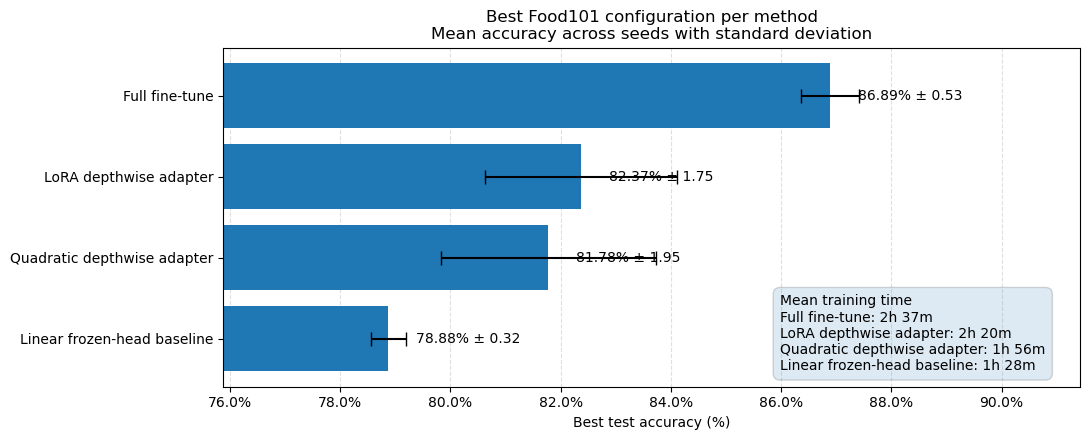

In [265]:
# Clearer plot: mean best test accuracy by method with std, exact score labels,
# and mean training time per method in a box.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

mean_col = "best_test_acc_mean"
std_col = "best_test_acc_std"
time_col = "training_time_sec"

plot_df = summary_by_method.copy()

# Convert 0.81-style accuracies to 81%-style values automatically.
scale = 100 if plot_df[mean_col].max() <= 1.5 else 1

plot_df["score_pct"] = plot_df[mean_col] * scale
plot_df["std_pct"] = plot_df[std_col].fillna(0) * scale

# Nicer labels.
method_labels = {
    "quad_dw": "Quadratic adapter",
    "lora_dw": "LoRA",
    "full_finetune": "Full fine-tuning",
    "linear_base": "Linear base",
    "scratch": "Scratch",
}

plot_df["method_label"] = plot_df["method"].map(method_labels).fillna(plot_df["method"])

# Mean training time for the selected best configuration per method only.

selected_configs = summary_by_method[
    ["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"]
].copy()

best_config_runs = all_runs.merge(
    selected_configs,
    on=["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"],
    how="inner"
)

time_summary = (
    best_config_runs
    .dropna(subset=["training_time_sec"])
    .groupby("method")["training_time_sec"]
    .mean()
)

def format_seconds(seconds):
    if pd.isna(seconds):
        return "n/a"

    seconds = float(seconds)
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)

    if hours > 0:
        return f"{hours}h {minutes}m"
    return f"{minutes}m"

# Build text box content.
time_lines = ["Mean training time"]
for method in plot_df["method"]:
    label = method_labels.get(method, method)
    mean_time = time_summary.get(method, np.nan)
    time_lines.append(f"{label}: {format_seconds(mean_time)}")

time_text = "\n".join(time_lines)

# Sort from lowest to highest so best appears at the top.
plot_df = plot_df.sort_values("score_pct", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(4.5, 0.75 * len(plot_df))))

bars = ax.barh(
    plot_df["method_label"],
    plot_df["score_pct"],
    xerr=plot_df["std_pct"],
    capsize=5
)

ax.set_xlabel("Best test accuracy (%)")
ax.set_ylabel("")
ax.set_title("Best Food101 configuration per method\nMean accuracy across seeds with standard deviation")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Give labels enough room on the right.
right_limit = (plot_df["score_pct"] + plot_df["std_pct"]).max() + 4
left_limit = max(0, plot_df["score_pct"].min() - 3)
ax.set_xlim(left_limit, right_limit)

# Add exact score labels: mean ± std.
for bar, mean, std in zip(bars, plot_df["score_pct"], plot_df["std_pct"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    label = f"{mean:.2f}% ± {std:.2f}"
    ax.text(
        x + 0.5,
        y,
        label,
        va="center",
        fontsize=10
    )

# Add mean training time box.
ax.text(
    0.65,
    0.04,
    time_text,
    transform=ax.transAxes,
    fontsize=10,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.15
    )
)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "best_test_accuracy_by_method_with_std_and_time.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

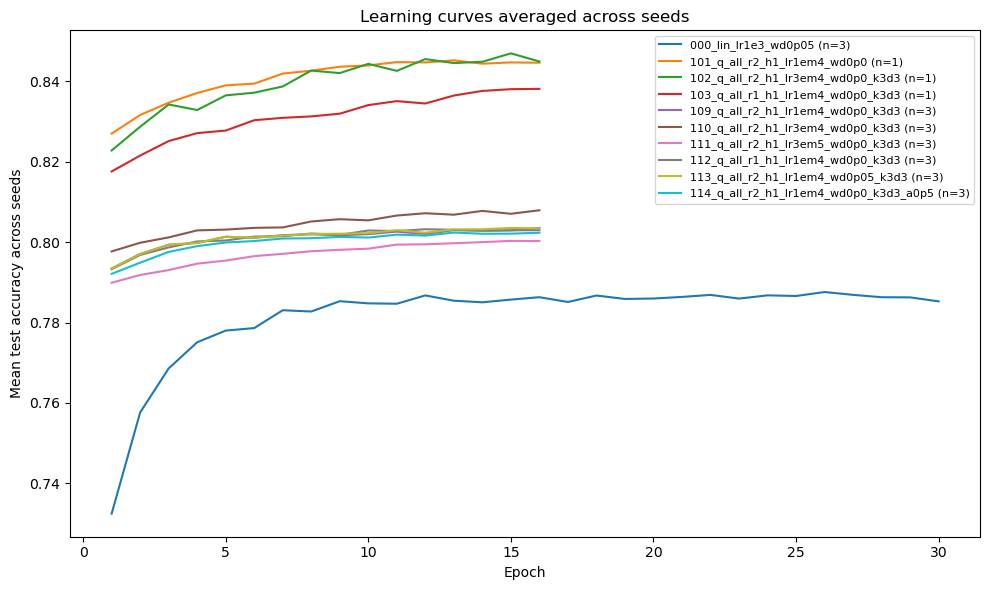

In [266]:
# Optional: inspect learning curves averaged across seeds.
selected_method = None    # e.g. "Quadratic depthwise adapter", or None for all
selected_run = None       # e.g. "209_l_all_r2_h1_lr1em4_wd0p0", or None for all

curve_df = epoch_history.copy()

if selected_method is not None:
    curve_df = curve_df[curve_df["method"] == selected_method]

if selected_run is not None:
    curve_df = curve_df[curve_df["run_name"] == selected_run]

# Average over seeds for each run and epoch
avg_curve_df = (
    curve_df
    .groupby(["run_name", "epoch"], as_index=False)
    .agg(
        mean_test_acc=("test_acc", "mean"),
        std_test_acc=("test_acc", "std"),
        num_seeds=("seed", "nunique"),
    )
)

# Plot only a small number of averaged curves
plt.figure(figsize=(10, 6))

plotted = 0
for run_name, group in avg_curve_df.groupby("run_name"):
    group = group.sort_values("epoch")

    plt.plot(
        group["epoch"],
        group["mean_test_acc"],
        label=f"{run_name} (n={group['num_seeds'].max()})",
    )

    plotted += 1
    if plotted >= 10:
        break

plt.xlabel("Epoch")
plt.ylabel("Mean test accuracy across seeds")
plt.title("Learning curves averaged across seeds")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

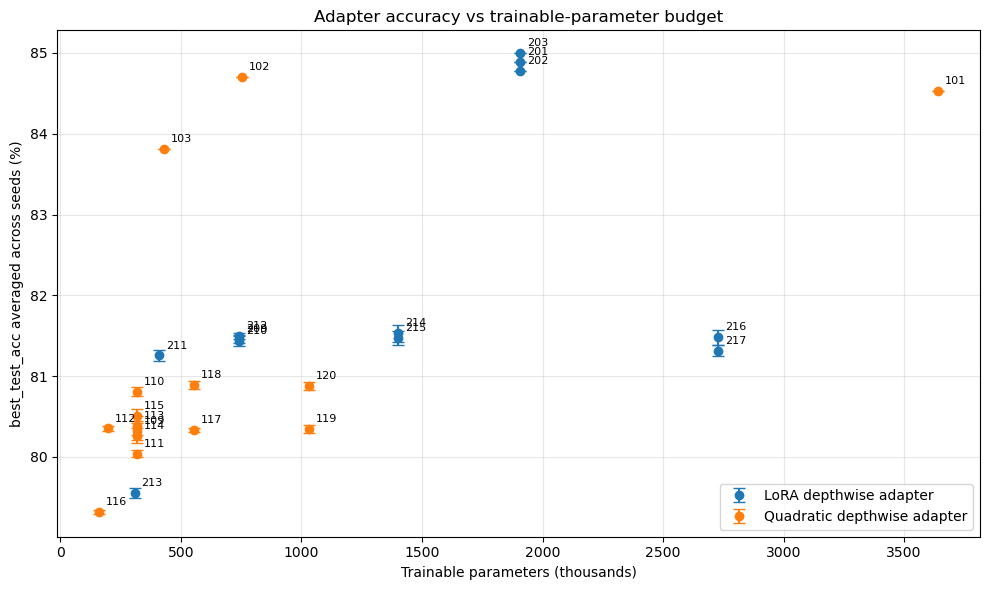

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use existing dataframe
df = all_runs.copy()

METRIC = "best_test_acc"   # or "final_test_acc"
LORA_METHOD = "LoRA depthwise adapter"
QUAD_METHOD = "Quadratic depthwise adapter"

# ------------------------------------------------------------
# 1. Average seeds per run
# ------------------------------------------------------------
adapter_df = df[df["method"].isin([LORA_METHOD, QUAD_METHOD])].copy()

summary = (
    adapter_df
    .groupby(
        [
            "run_name",
            "method",
            "stage",
            "scope",
            "rank",
            "train_head",
            "lr",
            "weight_decay",
            "trainable_params",
            "trainable_pct",
        ],
        as_index=False,
    )
    .agg(
        mean_acc=(METRIC, "mean"),
        std_acc=(METRIC, "std"),
        num_seeds=("seed", "nunique"),
    )
)

summary["mean_acc_pct"] = 100 * summary["mean_acc"]
summary["std_acc_pct"] = 100 * summary["std_acc"].fillna(0)
summary["trainable_params_k"] = summary["trainable_params"] / 1000

# ------------------------------------------------------------
# 2. Plot all runs: accuracy vs parameter budget
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

for method, group in summary.groupby("method"):
    group = group.sort_values("trainable_params")

    plt.errorbar(
        group["trainable_params_k"],
        group["mean_acc_pct"],
        yerr=group["std_acc_pct"],
        fmt="o",
        capsize=4,
        label=method,
    )

    # Small labels using run number only
    for _, row in group.iterrows():
        run_id = row["run_name"].split("_")[0]
        plt.annotate(
            run_id,
            (row["trainable_params_k"], row["mean_acc_pct"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.xlabel("Trainable parameters (thousands)")
plt.ylabel(f"{METRIC} averaged across seeds (%)")
plt.title("Adapter accuracy vs trainable-parameter budget")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [268]:
# ------------------------------------------------------------
# 3. Match every Quadratic run to closest LoRA run by parameter count
# ------------------------------------------------------------
quad = summary[summary["method"] == QUAD_METHOD].copy()
lora = summary[summary["method"] == LORA_METHOD].copy()

pairs = []

for _, q in quad.iterrows():
    candidates = lora.copy()
    candidates["param_diff_abs"] = (
        candidates["trainable_params"] - q["trainable_params"]
    ).abs()
    candidates["param_diff_pct"] = (
        candidates["param_diff_abs"] / q["trainable_params"] * 100
    )

    nearest = candidates.sort_values("param_diff_abs").iloc[0]

    pairs.append(
        {
            "quad_run": q["run_name"],
            "quad_params_k": q["trainable_params_k"],
            "quad_acc": q["mean_acc_pct"],
            "quad_std": q["std_acc_pct"],

            "nearest_lora_run": nearest["run_name"],
            "lora_params_k": nearest["trainable_params_k"],
            "lora_acc": nearest["mean_acc_pct"],
            "lora_std": nearest["std_acc_pct"],

            "param_diff_pct": nearest["param_diff_pct"],
            "quad_minus_lora_acc": q["mean_acc_pct"] - nearest["mean_acc_pct"],
        }
    )

pairs_df = pd.DataFrame(pairs)
pairs_df = pairs_df.sort_values("quad_params_k").reset_index(drop=True)

display(
    pairs_df[
        [
            "quad_run",
            "quad_params_k",
            "quad_acc",
            "nearest_lora_run",
            "lora_params_k",
            "lora_acc",
            "param_diff_pct",
            "quad_minus_lora_acc",
        ]
    ]
)

,quad_run,quad_params_k,quad_acc,nearest_lora_run,lora_params_k,lora_acc,param_diff_pct,quad_minus_lora_acc
0,116_q_ls_r2_h1_lr1em4_wd0p0_k3d3,160.613,79.318812,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,91.808260,-0.236304
1,112_q_all_r1_h1_lr1em4_wd0p0_k3d3,196.901,80.352475,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,56.458830,0.797360
2,109_q_all_r2_h1_lr1em4_wd0p0_k3d3,316.133,80.324752,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,0.769637
3,110_q_all_r2_h1_lr3em4_wd0p0_k3d3,316.133,80.806601,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,1.251485
4,111_q_all_r2_h1_lr3em5_wd0p0_k3d3,316.133,80.038284,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,0.483168
5,113_q_all_r2_h1_lr1em4_wd0p05_k3d3,316.133,80.386799,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,0.831683
6,114_q_all_r2_h1_lr1em4_wd0p0_k3d3_a0p5,316.133,80.262706,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,0.707591
7,115_q_all_r2_h1_lr1em4_wd0p0_k3d3_a2p0,316.133,80.506931,213_l_ls_r2_h1_lr1em4_wd0p0,308.069,79.555116,2.550825,0.951815
8,103_q_all_r1_h1_lr1em4_wd0p0_k3d3,428.389,83.813861,211_l_all_r1_h1_lr1em4_wd0p0,408.869,81.255446,4.556606,2.558416
9,117_q_all_r4_h1_lr1em4_wd0p0_k3d3,554.597,80.332673,211_l_all_r1_h1_lr1em4_wd0p0,408.869,81.255446,26.276377,-0.922772


In [269]:
import pandas as pd
import numpy as np

# Load both CSVs
df_atrous = pd.read_csv("/Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/analysis/result_tables/all_runs.csv")      # runs with k3d3 / atrous dilation
df_no_atrous = pd.read_csv("/Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/analysis/result_tables_4_test/all_runs.csv")   # runs without atrous dilation

# Mark source
df_atrous["sweep_variant"] = "atrous_k3d3"
df_no_atrous["sweep_variant"] = "non_atrous"

# Combine
all_combined = pd.concat([df_atrous, df_no_atrous], ignore_index=True)

# Add a clearer adapter-variant label
def get_adapter_variant(row):
    if row["stage"] == "quad_dw":
        if "_k3d3" in str(row["run_name"]):
            return "Quadratic atrous/dilated k3d3"
        else:
            return "Quadratic non-atrous"
    elif row["stage"] == "lora_dw":
        return "LoRA"
    elif row["stage"] == "linear_base":
        return "Linear frozen-head baseline"
    elif row["stage"] == "full_finetune":
        return "Full fine-tune"
    else:
        return row["stage"]

all_combined["adapter_variant"] = all_combined.apply(get_adapter_variant, axis=1)

# Remove duplicated baseline/full-finetune rows that appear in both CSVs
dedup_cols = [
    "seed",
    "dataset",
    "run_name",
    "stage",
    "scope",
    "rank",
    "train_head",
    "lr",
    "weight_decay",
    "epochs_completed",
    "trainable_params",
    "best_test_acc",
    "final_test_acc",
]

all_combined = all_combined.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

print(all_combined.shape)
print(all_combined["adapter_variant"].value_counts())

(164, 35)
adapter_variant
LoRA                             66
Quadratic non-atrous             41
Quadratic atrous/dilated k3d3    34
Full fine-tune                   15
Linear frozen-head baseline       8
Name: count, dtype: int64


In [270]:
METRIC = "best_test_acc"

summary = (
    all_combined
    .groupby(
        [
            "run_name",
            "method",
            "adapter_variant",
            "stage",
            "scope",
            "rank",
            "train_head",
            "lr",
            "weight_decay",
            "trainable_params",
            "trainable_pct",
        ],
        as_index=False,
    )
    .agg(
        mean_acc=(METRIC, "mean"),
        std_acc=(METRIC, "std"),
        num_seeds=("seed", "nunique"),
    )
)

summary["mean_acc_pct"] = 100 * summary["mean_acc"]
summary["std_acc_pct"] = 100 * summary["std_acc"].fillna(0)
summary["trainable_params_k"] = summary["trainable_params"] / 1000

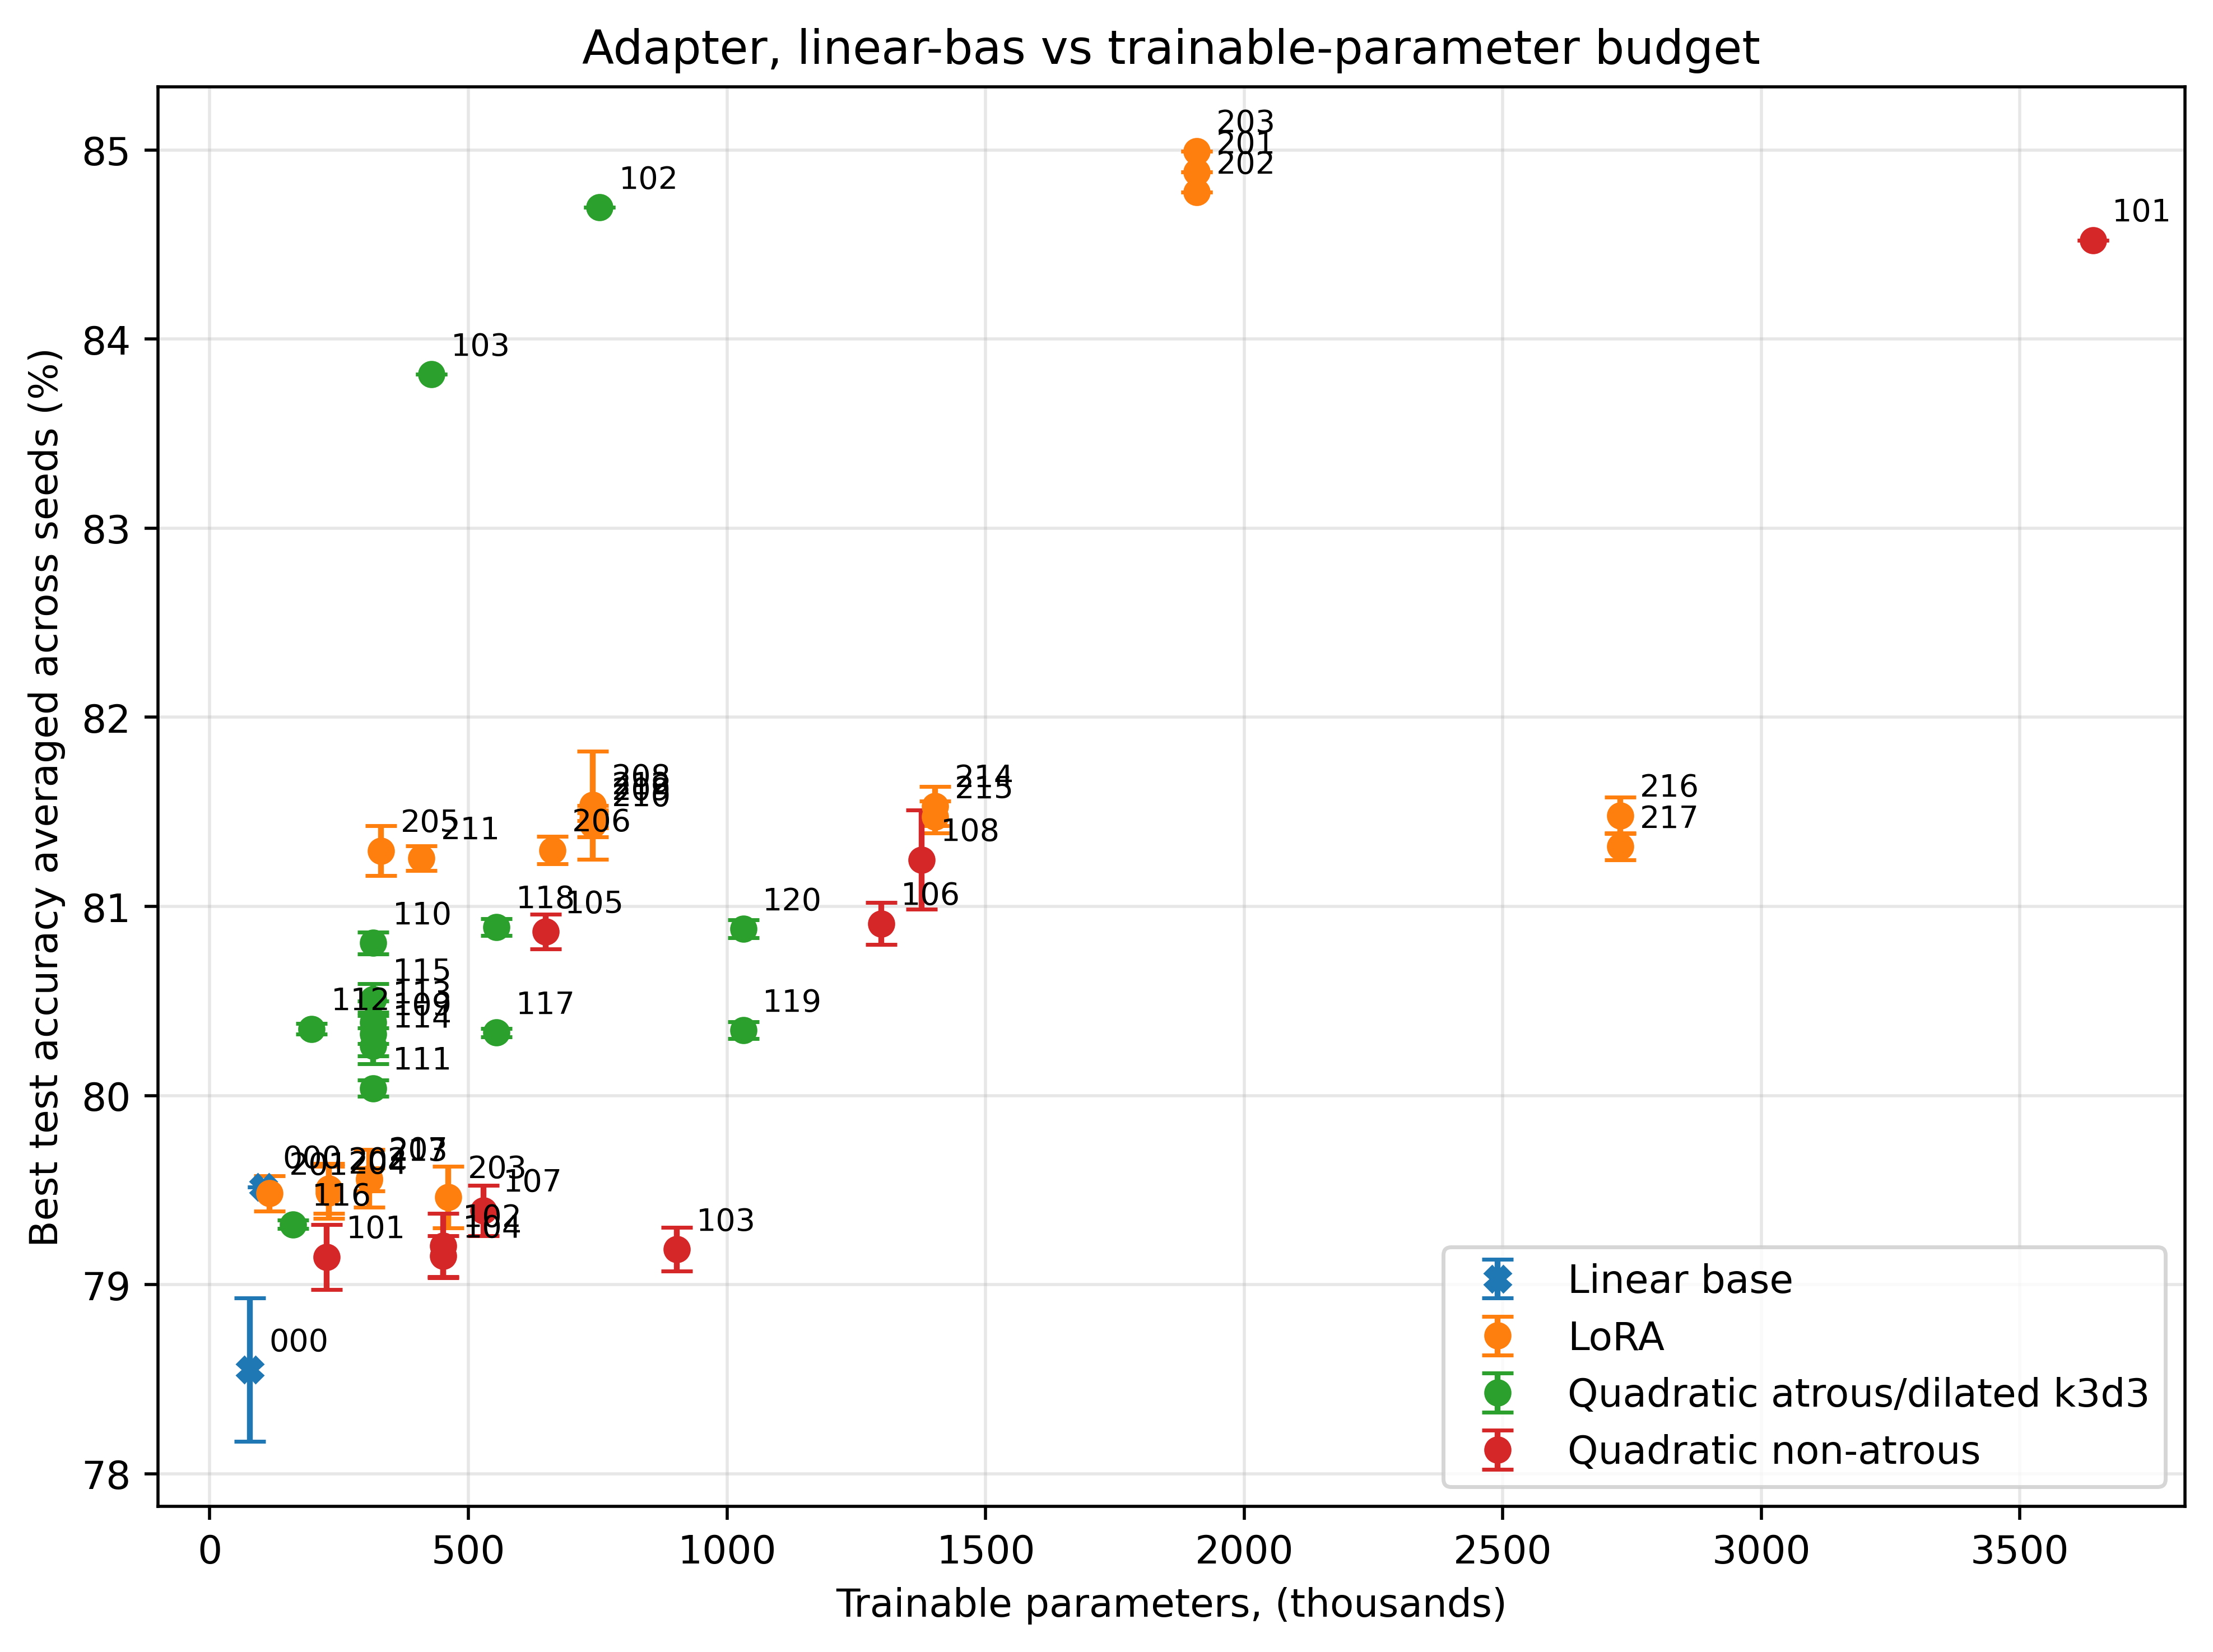

In [271]:
import matplotlib.pyplot as plt
import pandas as pd

METRIC = "best_test_acc"   # or "final_test_acc"

# Use your combined dataframe
df = all_combined.copy()

# ------------------------------------------------------------
# Make / update variant labels
# ------------------------------------------------------------
def get_variant(row):
    stage = str(row["stage"])
    run_name = str(row["run_name"])

    if stage == "quad_dw":
        if "_k3d3" in run_name:
            return "Quadratic atrous/dilated k3d3"
        else:
            return "Quadratic non-atrous"
    elif stage == "lora_dw":
        return "LoRA"
    elif stage == "linear_base":
        return "Linear base"
    elif stage == "full_finetune":
        return "Full fine-tune"
    else:
        return stage

df["adapter_variant"] = df.apply(get_variant, axis=1)

# ------------------------------------------------------------
# Average across seeds per unique run
# ------------------------------------------------------------
summary = (
    df
    .groupby(
        [
            "run_name",
            "method",
            "adapter_variant",
            "stage",
            "scope",
            "rank",
            "train_head",
            "lr",
            "weight_decay",
            "trainable_params",
            "trainable_pct",
        ],
        as_index=False,
    )
    .agg(
        mean_acc=(METRIC, "mean"),
        std_acc=(METRIC, "std"),
        num_seeds=("seed", "nunique"),
    )
)

summary["mean_acc_pct"] = 100 * summary["mean_acc"]
summary["std_acc_pct"] = 100 * summary["std_acc"].fillna(0)
summary["trainable_params_k"] = summary["trainable_params"] / 1000

# ------------------------------------------------------------
# Select categories to show
# ------------------------------------------------------------
plot_df = summary[
    summary["adapter_variant"].isin(
        [
            "Linear base",
            "LoRA",
            "Quadratic atrous/dilated k3d3",
            "Quadratic non-atrous",
        ]
    )
].copy()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 6),dpi=500)

markers = {
    "Linear base": "X",
    "LoRA": "o",
    "Quadratic atrous/dilated k3d3": "o",
    "Quadratic non-atrous": "o",
    "Full fine-tune": "D",
}

for variant, group in plot_df.groupby("adapter_variant"):
    group = group.sort_values("trainable_params")

    plt.errorbar(
        group["trainable_params_k"],
        group["mean_acc_pct"],
        yerr=group["std_acc_pct"],
        fmt=markers.get(variant, "o"),
        capsize=4,
        linestyle="none",
        label=variant,
    )

    for _, row in group.iterrows():
        run_id = str(row["run_name"]).split("_")[0]
        plt.annotate(
            run_id,
            (row["trainable_params_k"], row["mean_acc_pct"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.xlabel("Trainable parameters, (thousands)")
plt.ylabel("Best test accuracy averaged across seeds (%)")
plt.title("Adapter, linear-bas vs trainable-parameter budget")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [272]:
# Best configuration for each method/type
method_view_cols = [
    "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay", "n_seeds", "seeds",
    "best_test_acc_mean", "best_test_acc_std", "final_test_acc_mean",
    "training_time_hr_mean", "trainable_params_mean", "trainable_pct_mean", "run_names", 
]

display(summary_by_method[method_view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc_mean": "{:.4f}",
    "best_test_acc_std": "{:.4f}",
    "final_test_acc_mean": "{:.4f}",
    "training_time_hr_mean": "{:.2f}",
    "trainable_params_mean": "{:,.0f}",
    "trainable_pct_mean": "{:.2f}",
}))


,method,stage,scope,rank,train_head,lr,weight_decay,n_seeds,seeds,best_test_acc_mean,best_test_acc_std,final_test_acc_mean,training_time_hr_mean,trainable_params_mean,trainable_pct_mean,run_names
0,Full fine-tune,full_finetune,all,full,full,1.0e-04,0.01,3,"21,102,420",0.8689,0.0053,0.8605,2.62,"42,840,845",100.00,301_f_lr1e4_wd0p01
1,LoRA depthwise adapter,lora_dw,all,2,yes,1.0e-04,0.05,3,"21,102,420",0.8237,0.0175,0.8233,2.34,"1,032,133",2.48,"203_l_all_r2_h1_lr1em4_wd0p05,212_l_all_r2_h1_lr1em4_wd0p05"
2,Quadratic depthwise adapter,quad_dw,all,2,yes,3.0e-04,0,3,"21,102,420",0.8178,0.0195,0.8172,1.94,"425,413",1.06,"102_q_all_r2_h1_lr3em4_wd0p0_k3d3,110_q_all_r2_h1_lr3em4_wd0p0_k3d3"
3,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,3,"21,102,420",0.7888,0.0032,0.7853,1.47,"81,978",0.25,000_lin_lr1e3_wd0p05


In [273]:
summary

,run_name,method,adapter_variant,stage,scope,rank,train_head,lr,weight_decay,trainable_params,trainable_pct,mean_acc,std_acc,num_seeds,mean_acc_pct,std_acc_pct,trainable_params_k
0,000_lin_lr1e3_wd0p05,Linear frozen-head baseline,Linear base,linear_base,none,none,head_only,0.00100,0.05,77669,0.278405,0.785488,0.003791,7,78.548798,0.379116,77.669
1,000_lin_lr1e3_wd0p05,Linear frozen-head baseline,Linear base,linear_base,none,none,head_only,0.00100,0.05,103525,0.118085,0.795168,NaN,1,79.516832,0.000000,103.525
2,101_q_all_r2_h1_lr1em4_wd0p0,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,all,2,yes,0.00010,0.00,3640933,3.991927,0.845228,NaN,1,84.522772,0.000000,3640.933
3,101_q_ls_r1_h0_lr1em3_wd0p0,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,last_stage,1,no,0.00100,0.00,225792,0.802856,0.791461,0.001723,5,79.146139,0.172280,225.792
4,102_q_all_r2_h1_lr3em4_wd0p0_k3d3,Quadratic depthwise adapter,Quadratic atrous/dilated k3d3,quad_dw,all,2,yes,0.00030,0.00,753253,0.852871,0.846970,NaN,1,84.697030,0.000000,753.253
5,102_q_ls_r2_h0_lr1em3_wd0p0,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,last_stage,2,no,0.00100,0.00,451584,1.592924,0.792063,0.001712,5,79.206337,0.171229,451.584
6,103_q_all_r1_h1_lr1em4_wd0p0_k3d3,Quadratic depthwise adapter,Quadratic atrous/dilated k3d3,quad_dw,all,1,yes,0.00010,0.00,428389,0.486834,0.838139,NaN,1,83.813861,0.000000,428.389
7,103_q_ls_r4_h0_lr1em3_wd0p0,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,last_stage,4,no,0.00100,0.00,903168,3.135895,0.791865,0.001162,5,79.186535,0.116162,903.168
8,104_q_ls_r2_h0_lr3em4_wd0p01,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,last_stage,2,no,0.00030,0.01,451584,1.592924,0.791509,0.001082,5,79.150891,0.108192,451.584
9,105_q_all_r1_h0_lr3em4_wd0p0,Quadratic depthwise adapter,Quadratic non-atrous,quad_dw,all,1,no,0.00030,0.00,649152,2.273980,0.808665,0.000927,5,80.866535,0.092727,649.152


In [274]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

METRIC = "best_test_acc"   # or "final_test_acc"
TIME_COL = "effective_training_time_sec"  # fair time including linear base for adapters

df = all_combined.copy()

# ------------------------------------------------------------
# Basic cleanup
# ------------------------------------------------------------
df["seed"] = df["seed"].astype(str)
df["training_time_sec"] = pd.to_numeric(df["training_time_sec"], errors="coerce")

# ------------------------------------------------------------
# Make / update variant labels
# ------------------------------------------------------------
def get_variant(row):
    stage = str(row["stage"])
    run_name = str(row["run_name"])

    if stage == "quad_dw":
        if "_k3d3" in run_name:
            return "Quadratic atrous/dilated k3d3"
        else:
            return "Quadratic non-atrous"
    elif stage == "lora_dw":
        return "LoRA"
    elif stage == "linear_base":
        return "Linear base"
    elif stage == "full_finetune":
        return "Full fine-tune"
    else:
        return stage

df["adapter_variant"] = df.apply(get_variant, axis=1)

# ------------------------------------------------------------
# Add effective training time
# For adapters: linear_base time + adapter time
# For linear/full: own training time only
# ------------------------------------------------------------
linear_time_by_seed = (
    df[df["stage"] == "linear_base"]
    .groupby("seed")["training_time_sec"]
    .mean()
    .rename("linear_base_time_sec")
)

df = df.merge(linear_time_by_seed, on="seed", how="left")

df["own_training_time_sec"] = df["training_time_sec"]

df["effective_training_time_sec"] = np.where(
    df["stage"].isin(["quad_dw", "lora_dw"]),
    df["training_time_sec"] + df["linear_base_time_sec"],
    df["training_time_sec"],
)

missing_linear = df[
    df["stage"].isin(["quad_dw", "lora_dw"])
    & df["linear_base_time_sec"].isna()
]

if len(missing_linear) > 0:
    print("WARNING: Some adapter runs do not have a matching linear_base time by seed.")
    print(missing_linear[["seed", "run_name", "stage"]].drop_duplicates())

# ------------------------------------------------------------
# Make sure group columns exist
# ------------------------------------------------------------
group_cols = [
    "run_name",
    "method",
    "adapter_variant",
    "stage",
    "scope",
    "rank",
    "train_head",
    "lr",
    "weight_decay",
    "trainable_params",
    "trainable_pct",
]

for col in group_cols:
    if col not in df.columns:
        df[col] = np.nan

# Avoid groupby dropping linear/full rows because of NaNs
for col in ["scope", "rank", "train_head", "lr", "weight_decay", "method"]:
    df[col] = df[col].fillna("none")

# ------------------------------------------------------------
# Average across seeds per unique run
# ------------------------------------------------------------
summary = (
    df
    .groupby(group_cols, as_index=False, dropna=False)
    .agg(
        mean_acc=(METRIC, "mean"),
        std_acc=(METRIC, "std"),
        num_seeds=("seed", "nunique"),
        mean_own_time_sec=("own_training_time_sec", "mean"),
        std_own_time_sec=("own_training_time_sec", "std"),
        mean_effective_time_sec=("effective_training_time_sec", "mean"),
        std_effective_time_sec=("effective_training_time_sec", "std"),
    )
)

# Accuracy scale: handle both 0.81 and 81.0 formats
if summary["mean_acc"].max() <= 1.5:
    summary["mean_acc_pct"] = 100 * summary["mean_acc"]
    summary["std_acc_pct"] = 100 * summary["std_acc"].fillna(0)
else:
    summary["mean_acc_pct"] = summary["mean_acc"]
    summary["std_acc_pct"] = summary["std_acc"].fillna(0)

summary["trainable_params_k"] = summary["trainable_params"] / 1000
summary["mean_own_time_min"] = summary["mean_own_time_sec"] / 60
summary["std_own_time_min"] = summary["std_own_time_sec"].fillna(0) / 60
summary["mean_effective_time_min"] = summary["mean_effective_time_sec"] / 60
summary["std_effective_time_min"] = summary["std_effective_time_sec"].fillna(0) / 60

# ------------------------------------------------------------
# Select categories to show
# ------------------------------------------------------------
plot_df = summary[
    summary["adapter_variant"].isin(
        [
            "Linear base",
            "LoRA",
            "Quadratic atrous/dilated k3d3",
            "Quadratic non-atrous",
            "Full fine-tune",
        ]
    )
].copy()

plot_df = plot_df.dropna(subset=["mean_acc_pct", "trainable_params_k", "mean_effective_time_min"])

# Bubble sizes based on effective training time
t = plot_df["mean_effective_time_min"]
if t.max() > t.min():
    plot_df["bubble_size"] = 80 + 700 * (t - t.min()) / (t.max() - t.min())
else:
    plot_df["bubble_size"] = 250

markers = {
    "Linear base": "X",
    "LoRA": "o",
    "Quadratic atrous/dilated k3d3": "o",
    "Quadratic non-atrous": "o",
    "Full fine-tune": "D",
}

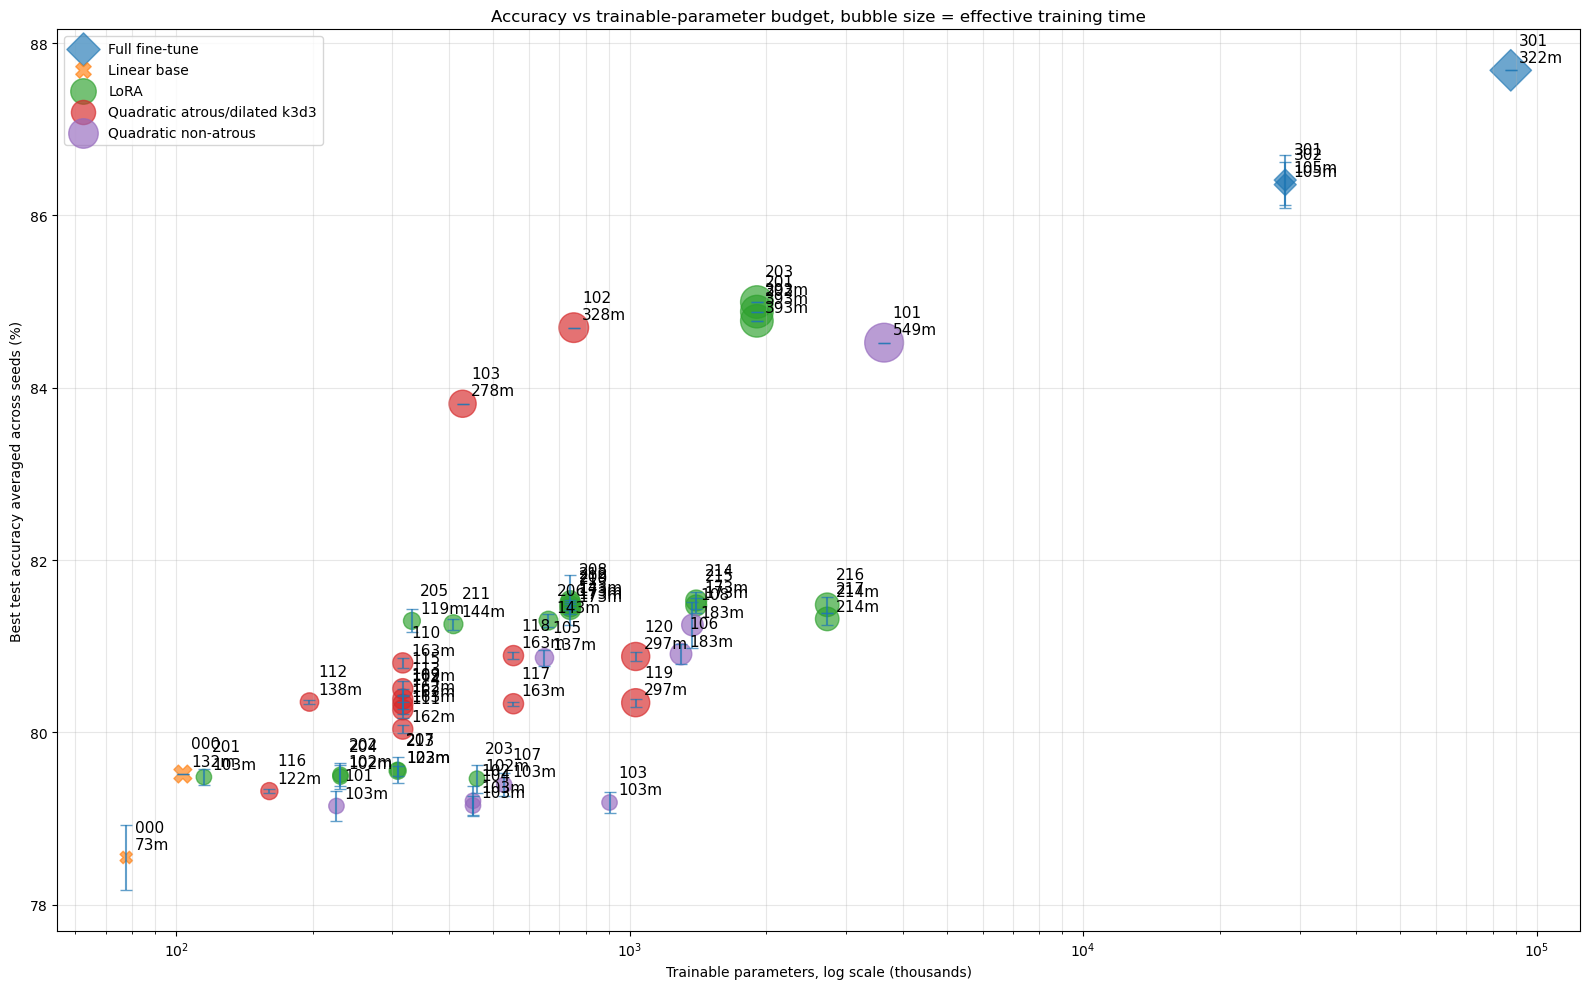

In [275]:
plt.figure(figsize=(16, 10))
ax = plt.gca()

for variant, group in plot_df.groupby("adapter_variant"):
    group = group.sort_values("trainable_params_k")

    ax.errorbar(
        group["trainable_params_k"],
        group["mean_acc_pct"],
        yerr=group["std_acc_pct"],
        fmt="none",
        capsize=4,
        alpha=0.7,
    )

    ax.scatter(
        group["trainable_params_k"],
        group["mean_acc_pct"],
        s=group["bubble_size"],
        marker=markers.get(variant, "o"),
        alpha=0.65,
        label=variant,
    )

    for _, row in group.iterrows():
        run_id = str(row["run_name"]).split("_")[0]
        label = f"{run_id}\n{row['mean_effective_time_min']:.0f}m"
        ax.annotate(
            label,
            (row["trainable_params_k"], row["mean_acc_pct"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=11,
        )

ax.set_xscale("log")
ax.set_xlabel("Trainable parameters, log scale (thousands)")
ax.set_ylabel("Best test accuracy averaged across seeds (%)")
ax.set_title("Accuracy vs trainable-parameter budget, bubble size = effective training time")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

              label budget  trainable_params_k  mean_acc_pct  mean_effective_time_min  effective_time_hr  num_seeds
   LoRA r=1 no head  ~320K             331.200     81.294257               119.133554           1.985559          5
    Quad atrous r=2  ~320K             316.133     80.806601               152.879580           2.547993          3
   LoRA r=2 no head  ~660K             662.400     81.297426               142.647904           2.377465          5
Quad non-atrous r=1  ~660K             649.152     80.866535               136.779595           2.279660          5
           LoRA r=4  ~1.4M            1402.469     81.603960               172.528613           2.875477          1
Quad non-atrous r=2  ~1.4M            1375.973     81.246733               183.226463           3.053774          5


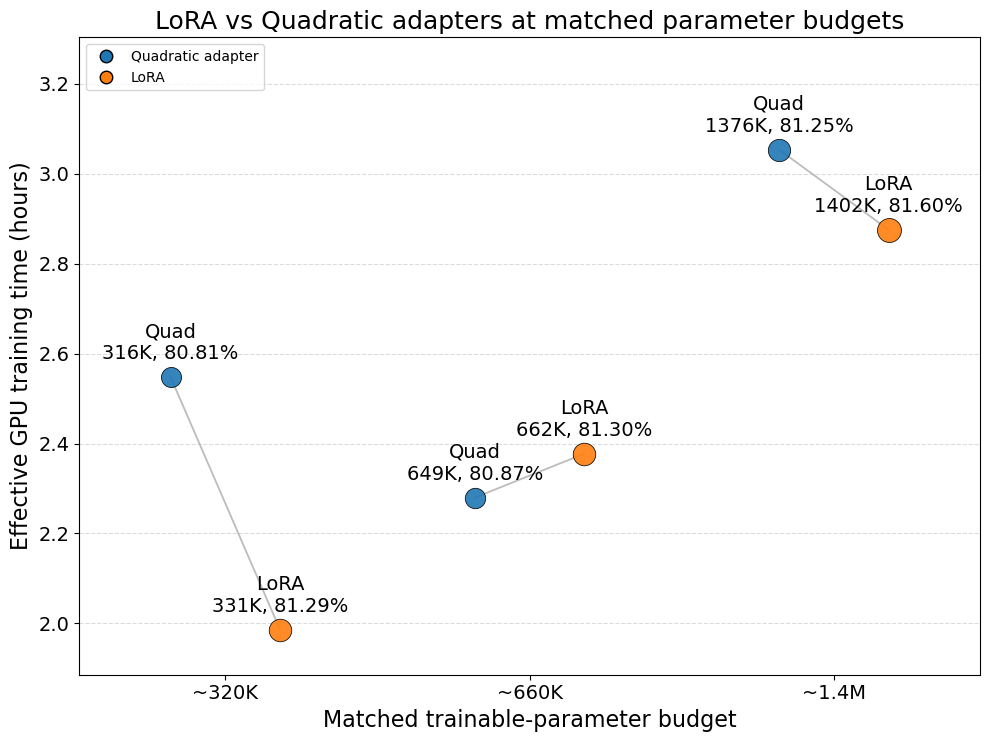

Saved to: result_tables/lora_vs_quad_effective_time_matched_params.png


In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# If OUT_DIR already exists in your notebook, this will use it.
# Otherwise it saves to the current folder.
try:
    OUT_DIR
except NameError:
    OUT_DIR = Path(".")
else:
    OUT_DIR = Path(OUT_DIR)

# Load summary file
summary_path = OUT_DIR / "summary_all.csv"

# If your file is somewhere else, use this instead:
# summary_path = Path("/mnt/data/summary_all(4).csv")

df = pd.read_csv(summary_path)

# Required columns
required_cols = [
    "run_name",
    "trainable_params_k",
    "mean_acc_pct",
    "mean_effective_time_min",
    "num_seeds",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in summary CSV: {missing}")

# Matched Quad vs LoRA parameter-budget comparisons
selected_run_names = [
    # ~320K budget
    "110_q_all_r2_h1_lr3em4_wd0p0_k3d3",  # Quad atrous r=2
    "205_l_all_r1_h0_lr3em4_wd0p0",       # LoRA r=1 no head

    # ~660K budget
    "105_q_all_r1_h0_lr3em4_wd0p0",       # Quad non-atrous r=1
    "206_l_all_r2_h0_lr3em4_wd0p0",       # LoRA r=2 no head

    # ~1.4M budget
    "108_q_all_r2_h1_lr1em4_wd0p0",       # Quad non-atrous r=2
    "214_l_all_r4_h1_lr1em4_wd0p0",       # LoRA r=4
]

plot_df = df[df["run_name"].isin(selected_run_names)].copy()

if len(plot_df) != len(selected_run_names):
    found = set(plot_df["run_name"])
    missing_runs = [r for r in selected_run_names if r not in found]
    print("Warning: these selected runs were not found:")
    for r in missing_runs:
        print("  -", r)

label_map = {
    "110_q_all_r2_h1_lr3em4_wd0p0_k3d3": "Quad atrous r=2",
    "205_l_all_r1_h0_lr3em4_wd0p0": "LoRA r=1 no head",
    "105_q_all_r1_h0_lr3em4_wd0p0": "Quad non-atrous r=1",
    "206_l_all_r2_h0_lr3em4_wd0p0": "LoRA r=2 no head",
    "108_q_all_r2_h1_lr1em4_wd0p0": "Quad non-atrous r=2",
    "214_l_all_r4_h1_lr1em4_wd0p0": "LoRA r=4",
}

budget_map = {
    "110_q_all_r2_h1_lr3em4_wd0p0_k3d3": "~320K",
    "205_l_all_r1_h0_lr3em4_wd0p0": "~320K",
    "105_q_all_r1_h0_lr3em4_wd0p0": "~660K",
    "206_l_all_r2_h0_lr3em4_wd0p0": "~660K",
    "108_q_all_r2_h1_lr1em4_wd0p0": "~1.4M",
    "214_l_all_r4_h1_lr1em4_wd0p0": "~1.4M",
}

method_map = {
    "110_q_all_r2_h1_lr3em4_wd0p0_k3d3": "Quad",
    "105_q_all_r1_h0_lr3em4_wd0p0": "Quad",
    "108_q_all_r2_h1_lr1em4_wd0p0": "Quad",
    "205_l_all_r1_h0_lr3em4_wd0p0": "LoRA",
    "206_l_all_r2_h0_lr3em4_wd0p0": "LoRA",
    "214_l_all_r4_h1_lr1em4_wd0p0": "LoRA",
}

plot_df["label"] = plot_df["run_name"].map(label_map)
plot_df["budget"] = plot_df["run_name"].map(budget_map)
plot_df["method"] = plot_df["run_name"].map(method_map)
plot_df["effective_time_hr"] = plot_df["mean_effective_time_min"] / 60.0

budget_order = ["~320K", "~660K", "~1.4M"]
budget_to_x = {b: i for i, b in enumerate(budget_order)}
method_offset = {"Quad": -0.18, "LoRA": 0.18}

plot_df["x_base"] = plot_df["budget"].map(budget_to_x)
plot_df["x"] = plot_df["x_base"] + plot_df["method"].map(method_offset)

plot_df = plot_df.sort_values(["x_base", "method"])

# Print table used for the plot
display_cols = [
    "label",
    "budget",
    "trainable_params_k",
    "mean_acc_pct",
    "mean_effective_time_min",
    "effective_time_hr",
    "num_seeds",
]
print(plot_df[display_cols].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Fixed method colors
method_colors = {
    "Quad": "tab:blue",
    "LoRA": "tab:orange",
}

# Connect Quad and LoRA inside each matched parameter budget
# Use neutral connector lines because each pair connects two different methods
for budget in budget_order:
    pair = plot_df[plot_df["budget"] == budget].sort_values("method")
    if len(pair) == 2:
        ax.plot(
            pair["x"],
            pair["effective_time_hr"],
            color="0.65",
            linewidth=1.3,
            alpha=0.75,
            zorder=1,
        )

# Scatter points
for _, row in plot_df.iterrows():
    marker_size = 120 + max(row["mean_acc_pct"] - 80.0, 0) * 110

    ax.scatter(
        row["x"],
        row["effective_time_hr"],
        s=marker_size,
        color=method_colors[row["method"]],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
        zorder=2,
    )

    seed_note = "" if row["num_seeds"] > 1 else ", n=1"

    text = (
        f"{row['method']}\n"
        f"{row['trainable_params_k']:.0f}K, "
        f"{row['mean_acc_pct']:.2f}%"
    )

    ax.annotate(
        text,
        xy=(row["x"], row["effective_time_hr"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=14,
    )

ax.set_xticks(range(len(budget_order)))
ax.set_xticklabels(budget_order)

ax.set_xlabel("Matched trainable-parameter budget", fontsize=16)
ax.set_ylabel("Effective GPU training time (hours)", fontsize=16)
ax.set_title("LoRA vs Quadratic adapters at matched parameter budgets", fontsize=18)

ax.tick_params(axis="both", labelsize=14)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.45)

# Legend
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Quadratic adapter",
        markerfacecolor=method_colors["Quad"],
        markeredgecolor="black",
        markersize=9,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="LoRA",
        markerfacecolor=method_colors["LoRA"],
        markeredgecolor="black",
        markersize=9,
    ),
]

ax.legend(handles=legend_handles, loc="upper left", frameon=True,)

# Add extra space so labels do not leave the plot box
# Extra room for labels
y_min = plot_df["effective_time_hr"].min()
y_max = plot_df["effective_time_hr"].max()
ax.set_ylim(y_min - 0.10, y_max + 0.25)

x_min = plot_df["x"].min()
x_max = plot_df["x"].max()
ax.set_xlim(x_min - 0.30, x_max + 0.3)


plt.tight_layout(rect=(0, 0.06, 1, 1))

out_path = OUT_DIR / "lora_vs_quad_effective_time_matched_params.png"
plt.savefig(out_path, dpi=500, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

Columns in all_runs:
['sweep', 'seed', 'dataset', 'run_name', 'grid_id', 'method', 'stage', 'scope', 'rank', 'train_head', 'lr', 'weight_decay', 'epochs_completed', 'final_train_loss', 'final_train_acc', 'final_test_loss', 'final_test_acc', 'best_train_acc', 'best_train_acc_epoch', 'best_test_acc', 'best_test_acc_epoch', 'best_test_loss', 'best_test_loss_epoch', 'best_minus_final_test_acc', 'final_generalization_gap', 'trainable_params', 'total_params', 'trainable_pct', 'training_time_sec', 'training_time_min', 'training_time_hr', 'base_checkpoint', 'metrics_path', 'sweep_variant', 'adapter_variant']

Detected method mapping:
                     method    method_key
Linear frozen-head baseline   linear_base
Quadratic depthwise adapter       quad_dw
     LoRA depthwise adapter       lora_dw
             Full fine-tune full_finetune

Rows used for plot:
    plot_label                          run_name                      method    method_key   acc_pct  acc_std_pct  params_k  raw_time_s

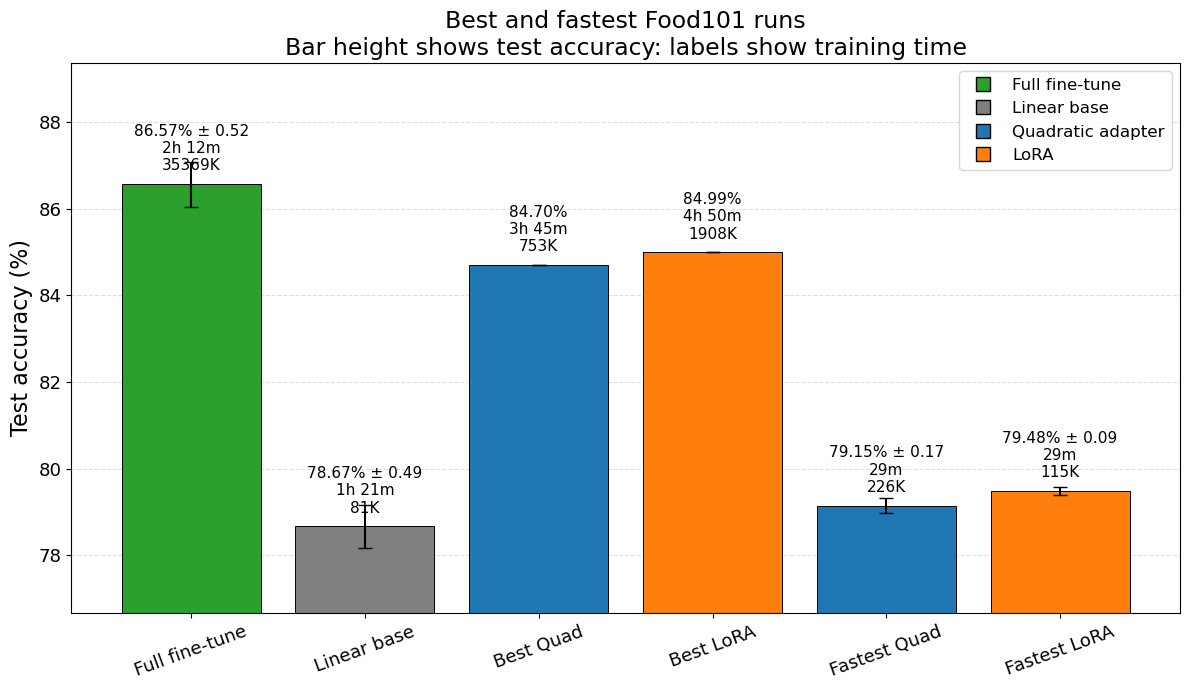


Saved to: result_tables/best_and_fastest_runs_accuracy_with_time.png


In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ============================================================
# Settings
# ============================================================

USE_EFFECTIVE_TIME = False
# True  = for Quad/LoRA, add the frozen-head linear baseline time
# False = use raw training time only

try:
    OUT_DIR
except NameError:
    OUT_DIR = Path(".")
else:
    OUT_DIR = Path(OUT_DIR)

# If all_runs is not already loaded, uncomment this:
# all_runs = pd.read_csv(OUT_DIR / "all_runs.csv")

# ============================================================
# Helper functions
# ============================================================

def format_seconds(seconds):
    if pd.isna(seconds):
        return "n/a"

    total_minutes = int(round(float(seconds) / 60))
    hours = total_minutes // 60
    minutes = total_minutes % 60

    if hours > 0:
        return f"{hours}h {minutes:02d}m"
    return f"{minutes}m"


def normalize_method_name(x):
    """Convert method names from your notebook into stable method keys."""
    if pd.isna(x):
        return np.nan

    s = str(x).lower()

    if "full" in s:
        return "full_finetune"

    if "linear" in s or "frozen-head" in s or "frozen head" in s:
        return "linear_base"

    if "quad" in s or "quadratic" in s:
        return "quad_dw"

    if "lora" in s:
        return "lora_dw"

    return np.nan


def pick_best(config_summary, method_key):
    subset = config_summary[config_summary["method_key"] == method_key].copy()

    if subset.empty:
        print("Available methods:")
        print(config_summary[["method", "method_key"]].drop_duplicates())
        raise ValueError(f"No runs found for method_key: {method_key}")

    return subset.sort_values("acc_pct", ascending=False).iloc[0]


def pick_fastest(config_summary, method_key):
    subset = config_summary[config_summary["method_key"] == method_key].copy()

    if subset.empty:
        print("Available methods:")
        print(config_summary[["method", "method_key"]].drop_duplicates())
        raise ValueError(f"No runs found for method_key: {method_key}")

    # First choose lowest rounded minute.
    # If several runs have same rounded minute, choose lowest params.
    # If still tied, choose highest accuracy.
    return subset.sort_values(
        ["plot_time_min_rounded", "params_k", "acc_pct"],
        ascending=[True, True, False]
    ).iloc[0]


# ============================================================
# Check input dataframe
# ============================================================

all_runs = all_runs.copy()
all_runs = all_combined.copy()

print("Columns in all_runs:")
print(all_runs.columns.tolist())

# Accuracy column detection
acc_candidates = [
    "best_test_acc",
    "test_acc",
    "test_accuracy",
    "best_test_accuracy",
]

acc_col = next((c for c in acc_candidates if c in all_runs.columns), None)

if acc_col is None:
    raise ValueError(f"Could not find accuracy column. Tried: {acc_candidates}")

if "training_time_sec" not in all_runs.columns:
    raise ValueError("Expected column 'training_time_sec' in all_runs.")

# Parameter column detection
if "trainable_params_k" in all_runs.columns:
    param_col = "trainable_params_k"
elif "trainable_params" in all_runs.columns:
    param_col = "trainable_params"
else:
    param_col = None
    print("Warning: no trainable parameter column found.")

# ============================================================
# Normalize method names
# ============================================================

all_runs["method_key"] = all_runs["method"].apply(normalize_method_name)

# Fallback using stage, if method names are strange
if "stage" in all_runs.columns:
    all_runs.loc[
        all_runs["method_key"].isna() & all_runs["stage"].astype(str).str.contains("linear", case=False, na=False),
        "method_key"
    ] = "linear_base"

    all_runs.loc[
        all_runs["method_key"].isna() & all_runs["stage"].astype(str).str.contains("quad", case=False, na=False),
        "method_key"
    ] = "quad_dw"

    all_runs.loc[
        all_runs["method_key"].isna() & all_runs["stage"].astype(str).str.contains("lora", case=False, na=False),
        "method_key"
    ] = "lora_dw"

print("\nDetected method mapping:")
print(all_runs[["method", "method_key"]].drop_duplicates().to_string(index=False))

if all_runs["method_key"].isna().any():
    print("\nWarning: some rows have unknown method_key:")
    print(all_runs.loc[all_runs["method_key"].isna(), ["method"]].drop_duplicates())


# ============================================================
# Build per-configuration summary
# ============================================================

possible_config_cols = [
    "run_name",
    "method",
    "method_key",
    "stage",
    "scope",
    "rank",
    "train_head",
    "lr",
    "weight_decay",
    "kernel_size",
    "kernel",
    "dilation",
    "dilation_rate",
]

config_cols = [c for c in possible_config_cols if c in all_runs.columns]

if "method_key" not in config_cols:
    raise ValueError("method_key was not created correctly.")

agg_dict = {
    acc_col: ["mean", "std", "count"],
    "training_time_sec": "mean",
}

if param_col is not None:
    agg_dict[param_col] = "mean"

config_summary = (
    all_runs
    .dropna(subset=[acc_col])
    .groupby(config_cols, dropna=False)
    .agg(agg_dict)
    .reset_index()
)

# Flatten multi-index columns
new_cols = []
for col in config_summary.columns:
    if isinstance(col, tuple):
        if col[1] == "":
            new_cols.append(col[0])
        else:
            new_cols.append(f"{col[0]}_{col[1]}")
    else:
        new_cols.append(col)

config_summary.columns = new_cols

config_summary = config_summary.rename(
    columns={
        f"{acc_col}_mean": "acc_mean",
        f"{acc_col}_std": "acc_std",
        f"{acc_col}_count": "num_seeds",
        "training_time_sec_mean": "raw_time_sec",
    }
)

# Convert accuracy to percent if needed
scale = 100 if config_summary["acc_mean"].max() <= 1.5 else 1
config_summary["acc_pct"] = config_summary["acc_mean"] * scale
config_summary["acc_std_pct"] = config_summary["acc_std"].fillna(0) * scale

# Convert params to K
if param_col == "trainable_params_k":
    config_summary["params_k"] = config_summary[f"{param_col}_mean"]
elif param_col == "trainable_params":
    config_summary["params_k"] = config_summary[f"{param_col}_mean"] / 1000
else:
    config_summary["params_k"] = np.nan

# ============================================================
# Effective training time
# ============================================================

config_summary["plot_time_sec"] = config_summary["raw_time_sec"]

if USE_EFFECTIVE_TIME:
    linear_configs = config_summary[config_summary["method_key"] == "linear_base"].copy()

    if len(linear_configs) > 0:
        best_linear = linear_configs.sort_values("acc_pct", ascending=False).iloc[0]
        linear_baseline_time_sec = best_linear["raw_time_sec"]

        adapter_mask = config_summary["method_key"].isin(["quad_dw", "lora_dw"])
        config_summary.loc[adapter_mask, "plot_time_sec"] = (
            config_summary.loc[adapter_mask, "raw_time_sec"] + linear_baseline_time_sec
        )

        print(f"\nUsing linear baseline time for effective adapter time: {format_seconds(linear_baseline_time_sec)}")
    else:
        print("\nWarning: no linear_base run found, so effective time equals raw time.")

config_summary["plot_time_hr"] = config_summary["plot_time_sec"] / 3600
# Rounded time in minutes, used for fastest-run tie-breaking
config_summary["plot_time_min_rounded"] = (
    config_summary["plot_time_sec"] / 60
).round().astype(int)

# ============================================================
# Select bars in requested order
# ============================================================

rows = []

full_best = pick_best(config_summary, "full_finetune")
full_best["plot_label"] = "Full fine-tune"
full_best["selection"] = "Best"
rows.append(full_best)

linear_best = pick_best(config_summary, "linear_base")
linear_best["plot_label"] = "Linear base"
linear_best["selection"] = "Best"
rows.append(linear_best)

quad_best = pick_best(config_summary, "quad_dw")
quad_best["plot_label"] = "Best Quad"
quad_best["selection"] = "Best"
rows.append(quad_best)

lora_best = pick_best(config_summary, "lora_dw")
lora_best["plot_label"] = "Best LoRA"
lora_best["selection"] = "Best"
rows.append(lora_best)

quad_fast = pick_fastest(config_summary, "quad_dw")
quad_fast["plot_label"] = "Fastest Quad"
quad_fast["selection"] = "Fastest"
rows.append(quad_fast)

lora_fast = pick_fastest(config_summary, "lora_dw")
lora_fast["plot_label"] = "Fastest LoRA"
lora_fast["selection"] = "Fastest"
rows.append(lora_fast)

plot_df = pd.DataFrame(rows).reset_index(drop=True)

# ============================================================
# Print values used in the plot
# ============================================================

print_cols = [
    "plot_label",
    "method",
    "method_key",
    "acc_pct",
    "acc_std_pct",
    "params_k",
    "raw_time_sec",
    "plot_time_sec",
    "num_seeds",
]

if "run_name" in plot_df.columns:
    print_cols.insert(1, "run_name")

print("\nRows used for plot:")
print(plot_df[print_cols].to_string(index=False))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

method_colors = {
    "full_finetune": "tab:green",
    "linear_base": "tab:grey",
    "quad_dw": "tab:blue",
    "lora_dw": "tab:orange",
}

bar_colors = [method_colors.get(m, "0.5") for m in plot_df["method_key"]]

bars = ax.bar(
    plot_df["plot_label"],
    plot_df["acc_pct"],
    yerr=plot_df["acc_std_pct"],
    capsize=5,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.7,
)

ax.set_ylabel("Test accuracy (%)", fontsize=16)
ax.set_xlabel("", fontsize=16)

time_name = "effective GPU training time" if USE_EFFECTIVE_TIME else "training time"

ax.set_title(
    f"Best and fastest Food101 runs\nBar height shows test accuracy: labels show {time_name}",
    fontsize=17,
)

ax.tick_params(axis="x", labelsize=13, rotation=20)
ax.tick_params(axis="y", labelsize=13)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Focus y-axis on relevant accuracy range
y_min = max(0, plot_df["acc_pct"].min() - 2.0)
y_max = plot_df["acc_pct"].max() + 2.8
ax.set_ylim(y_min, y_max)

# Labels above bars
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    time_text = format_seconds(row["plot_time_sec"])
    params_text = "n/a" if pd.isna(row["params_k"]) else f"{row['params_k']:.0f}K"
    seed_text = f"n={int(row['num_seeds'])}"

    std_text = ""
    if row["num_seeds"] > 1:
        std_text = f" ± {row['acc_std_pct']:.2f}"

    label = (
        f"{row['acc_pct']:.2f}%{std_text}"
        f"\n{time_text}"
        f"\n{params_text}"
    )

    ax.text(
        x,
        y + 0.25,
        label,
        ha="center",
        va="bottom",
        fontsize=11,
    )

# Legend
legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="Full fine-tune",
        markerfacecolor=method_colors["full_finetune"],
        markeredgecolor="black",
        markersize=10,
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="Linear base",
        markerfacecolor=method_colors["linear_base"],
        markeredgecolor="black",
        markersize=10,
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="Quadratic adapter",
        markerfacecolor=method_colors["quad_dw"],
        markeredgecolor="black",
        markersize=10,
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="LoRA",
        markerfacecolor=method_colors["lora_dw"],
        markeredgecolor="black",
        markersize=10,
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=12,
    frameon=True,
)

plt.tight_layout()

out_path = OUT_DIR / "best_and_fastest_runs_accuracy_with_time.png"
plt.savefig(out_path, dpi=500, bbox_inches="tight")
plt.show()

print(f"\nSaved to: {out_path}")

In [280]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# Settings
# ============================================================

try:
    OUT_DIR
except NameError:
    OUT_DIR = Path(".")
else:
    OUT_DIR = Path(OUT_DIR)

df = all_combined.copy()

# Mark ConvNeXt backbone from the sweep/folder name.
# The A100 side experiment lives in:
# food101_a100_convnext_base_compact_28689102
if "sweep" in df.columns:
    sweep_text = df["sweep"].astype(str)
else:
    sweep_text = pd.Series([""] * len(df), index=df.index)

df["Backbone"] = np.where(
    sweep_text.str.contains("convnext_base|a100_convnext_base|base_compact", case=False, na=False),
    "Base",
    "Tiny"
)

# Use adapter/raw training time, not linear + adapter effective time
USE_EFFECTIVE_TIME = False

# ============================================================
# Helper functions
# ============================================================

def format_seconds(seconds):
    if pd.isna(seconds):
        return "n/a"

    seconds = float(seconds)
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)

    if hours > 0:
        return f"{hours}h {minutes:02d}m"
    return f"{minutes}m"


def format_minutes(minutes):
    if pd.isna(minutes):
        return "n/a"
    return format_seconds(float(minutes) * 60)


def format_params_k(x):
    if pd.isna(x):
        return "n/a"

    x = float(x)

    if x >= 1000:
        return f"{x/1000:.1f}M"
    return f"{x:.1f}K"


def format_lr(x):
    if pd.isna(x):
        return ""

    x = float(x)

    if np.isclose(x, 3e-4):
        return r"$3{\times}10^{-4}$"
    if np.isclose(x, 1e-4):
        return r"$1{\times}10^{-4}$"
    if np.isclose(x, 1e-3):
        return r"$1{\times}10^{-3}$"

    return f"{x:.0e}"


def format_head(x):
    if pd.isna(x):
        return ""

    try:
        return "head" if bool(int(x)) else "no head"
    except Exception:
        return "head" if bool(x) else "no head"
    

def extract_run_id(run_name):
    if pd.isna(run_name):
        return ""

    s = str(run_name)

    # Examples:
    # "112_q_all_r4_h1_lr3em4_wd0p0_k3d3" -> "112"
    # "000_linear_base" -> "000"
    # "202_l_all_r1_h1_lr3em4_wd0p0" -> "202"
    if "_" in s:
        prefix = s.split("_")[0]
        if prefix.isdigit():
            return prefix

    return ""

def normalize_model_name(row):
    method = str(row.get("method", "")).lower()
    stage = str(row.get("stage", "")).lower()
    run_name = str(row.get("run_name", "")).lower()
    label = str(row.get("label", "")).lower()

    text = " ".join([method, stage, run_name, label])

    if "full" in text:
        return "Full fine-tune"

    if "linear" in text or "frozen-head" in text or "frozen head" in text:
        return "Linear base"

    if "lora" in text or "_l_" in text:
        return "LoRA"

    if "quad" in text or "quadratic" in text or "_q_" in text:
        if "k3d3" in text or "atrous" in text:
            return "Quad, atrous"
        return "Quad, non-atrous"

    return row.get("method", "Unknown")


def format_scope(x):
    if pd.isna(x):
        return ""

    s = str(x)

    if s == "all":
        return "all"
    if s == "last_stage":
        return "last stage"
    if s == "none":
        return ""

    return s.replace("_", " ")


def format_wd(x):
    if pd.isna(x):
        return ""

    x = float(x)

    if np.isclose(x, 0.0):
        return "0"
    if np.isclose(x, 0.01):
        return "0.01"
    if np.isclose(x, 0.05):
        return "0.05"

    return f"{x:g}"


def build_config(row):
    model = row["Model"]

    scope_text = ""
    if "scope" in row and not pd.isna(row["scope"]):
        scope = format_scope(row["scope"])
        if scope:
            scope_text = f"{scope}, "

    if model == "Linear base":
        wd_text = ""
        if "weight_decay" in row and not pd.isna(row["weight_decay"]):
            wd_text = f", wd={format_wd(row['weight_decay'])}"
        return "head only" + wd_text

    if model == "Full fine-tune":
        parts = []

        if "lr" in row and not pd.isna(row["lr"]):
            parts.append(rf"lr={format_lr(row['lr'])}")

        if "weight_decay" in row and not pd.isna(row["weight_decay"]):
            parts.append(rf"wd={format_wd(row['weight_decay'])}")

        return scope_text + ", ".join(parts)

    parts = []

    if "rank" in row and not pd.isna(row["rank"]):
        parts.append(rf"$r={int(row['rank'])}$")

    if "lr" in row and not pd.isna(row["lr"]):
        parts.append(rf"lr={format_lr(row['lr'])}")

    if "weight_decay" in row and not pd.isna(row["weight_decay"]):
        parts.append(rf"wd={format_wd(row['weight_decay'])}")

    if "train_head" in row and not pd.isna(row["train_head"]):
        parts.append(format_head(row["train_head"]))

    return scope_text + ", ".join([p for p in parts if p])


# ============================================================
# Show columns, useful for debugging
# ============================================================

print("Columns in all_combined:")
print(df.columns.tolist())

# ============================================================
# Detect accuracy columns
# ============================================================

# If all_combined is already summarized, prefer mean columns.
summary_acc_candidates = [
    "mean_acc_pct",
    "test_acc_mean",
    "best_test_acc_mean",
    "mean_best_test_acc",
    "acc_pct",
]

raw_acc_candidates = [
    "best_test_acc",
    "test_acc",
    "test_accuracy",
    "best_test_accuracy",
]

summary_acc_col = next((c for c in summary_acc_candidates if c in df.columns), None)
raw_acc_col = next((c for c in raw_acc_candidates if c in df.columns), None)

if summary_acc_col is None and raw_acc_col is None:
    raise ValueError(
        "Could not find an accuracy column. "
        f"Tried summary columns {summary_acc_candidates} and raw columns {raw_acc_candidates}."
    )

# ============================================================
# Detect std / seeds if already summarized
# ============================================================

std_candidates = [
    "std_acc_pct",
    "test_acc_std",
    "best_test_acc_std",
    "acc_std",
    "mean_acc_std",
]

seed_candidates = [
    "num_seeds",
    "n_seeds",
    "seeds",
    "count",
]

std_col = next((c for c in std_candidates if c in df.columns), None)
seed_col = next((c for c in seed_candidates if c in df.columns), None)

# ============================================================
# Detect parameter columns
# ============================================================

if "trainable_params_k" in df.columns:
    df["params_k_raw"] = df["trainable_params_k"]
elif "trainable_params" in df.columns:
    df["params_k_raw"] = df["trainable_params"] / 1000
else:
    df["params_k_raw"] = np.nan
    print("Warning: no trainable parameter column found.")

# ============================================================
# Detect training time columns
# ============================================================

# Adapter/raw time candidates
adapter_time_min_candidates = [
    "mean_training_time_min",
    "mean_train_time_min",
    "training_time_min",
    "train_time_min",
    "adapter_time_min",
    "mean_adapter_time_min",
]

adapter_time_sec_candidates = [
    "training_time_sec",
    "mean_training_time_sec",
    "train_time_sec",
    "adapter_time_sec",
    "mean_adapter_time_sec",
]

# Effective time candidates
effective_time_min_candidates = [
    "mean_effective_time_min",
    "effective_time_min",
]

effective_time_sec_candidates = [
    "mean_effective_time_sec",
    "effective_time_sec",
]

if USE_EFFECTIVE_TIME:
    time_min_col = next((c for c in effective_time_min_candidates if c in df.columns), None)
    time_sec_col = next((c for c in effective_time_sec_candidates if c in df.columns), None)
else:
    time_min_col = next((c for c in adapter_time_min_candidates if c in df.columns), None)
    time_sec_col = next((c for c in adapter_time_sec_candidates if c in df.columns), None)

if time_sec_col is not None:
    df["time_sec_raw"] = df[time_sec_col]
elif time_min_col is not None:
    df["time_sec_raw"] = df[time_min_col] * 60
else:
    df["time_sec_raw"] = np.nan
    print("Warning: no training-time column found.")

print("\nUsing columns:")
print("Accuracy mean/raw:", summary_acc_col if summary_acc_col else raw_acc_col)
print("Accuracy std:", std_col)
print("Seeds:", seed_col)
print("Time:", time_sec_col if time_sec_col else time_min_col)

# ============================================================
# Detect epochs
# ============================================================

if "epochs_completed" in df.columns:
    df["epochs_raw"] = df["epochs_completed"]
elif "epochs" in df.columns:
    df["epochs_raw"] = df["epochs"]
else:
    df["epochs_raw"] = np.nan

# ============================================================
# Add readable model names
# ============================================================

df["Model"] = df.apply(normalize_model_name, axis=1)

# ============================================================
# Case 1: all_combined is already summarized per config
# ============================================================

if summary_acc_col is not None:
    summary = df.copy()

    # Convert accuracy to percent if stored as 0.81 instead of 81.0
    scale = 100 if summary[summary_acc_col].max() <= 1.5 else 1
    summary["test_acc_mean"] = summary[summary_acc_col] * scale

    if std_col is not None:
        std_scale = 100 if summary[std_col].max() <= 1.5 else 1
        summary["test_acc_std"] = summary[std_col] * std_scale
    else:
        summary["test_acc_std"] = np.nan

    if seed_col is not None:
        summary["seeds"] = summary[seed_col]
    else:
        summary["seeds"] = 1

    summary["trainable_params_k"] = summary["params_k_raw"]
    summary["adapter_time_sec"] = summary["time_sec_raw"]
    summary["epochs_completed"] = summary["epochs_raw"]
    
    

# ============================================================
# Case 2: all_combined has one row per seed/run
# ============================================================

else:
    scale = 100 if df[raw_acc_col].max() <= 1.5 else 1
    df["test_acc_pct_raw"] = df[raw_acc_col] * scale

    possible_group_cols = [
        "Backbone",
        "run_name",
        "Model",
        "method",
        "stage",
        "scope",
        "rank",
        "train_head",
        "lr",
        "weight_decay",
        "kernel_size",
        "kernel",
        "dilation",
        "dilation_rate",
    ]

    group_cols = [c for c in possible_group_cols if c in df.columns]

    summary = (
        df
        .dropna(subset=["test_acc_pct_raw"])
        .groupby(group_cols, dropna=False)
        .agg(
            test_acc_mean=("test_acc_pct_raw", "mean"),
            test_acc_std=("test_acc_pct_raw", "std"),
            adapter_time_sec=("time_sec_raw", "mean"),
            trainable_params_k=("params_k_raw", "mean"),
            epochs_completed=("epochs_raw", "mean"),
            seeds=("test_acc_pct_raw", "count"),
        )
        .reset_index()
    )

# ============================================================
# Build clean display table
# ============================================================

summary["Config"] = summary.apply(build_config, axis=1)


summary["Run ID"] = summary.apply(
    lambda row: (
        "B" + extract_run_id(row["run_name"])
        if row["Backbone"] == "Base"
        else extract_run_id(row["run_name"])
    ),
    axis=1
)

summary["Trainable params"] = summary["trainable_params_k"].apply(format_params_k)

summary["Epochs"] = summary["epochs_completed"].apply(
    lambda x: "n/a" if pd.isna(x) else f"{int(round(float(x)))}"
)

summary["Test acc."] = summary.apply(
    lambda row: (
        f"{row['test_acc_mean']:.2f}\\%"
        if pd.isna(row["test_acc_std"]) or row["seeds"] <= 1
        else f"{row['test_acc_mean']:.2f}\\% $\\pm$ {row['test_acc_std']:.2f}"
    ),
    axis=1,
)

summary["Adapter time"] = summary["adapter_time_sec"].apply(format_seconds)
summary["Seeds"] = summary["seeds"].fillna(1).astype(int)

summary["Scope"] = summary["scope"].apply(format_scope) if "scope" in summary.columns else ""

# Keep run_name for debugging/reference if available
if "run_name" not in summary.columns:
    summary["run_name"] = ""

# Sort in useful order
model_order = {
    "Linear base": 0,
    "Quad, atrous": 1,
    "Quad, non-atrous": 2,
    "LoRA": 3,
    "Full fine-tune": 4,
}

summary["model_order"] = summary["Model"].map(model_order).fillna(99)

summary = summary.sort_values(
    ["model_order", "trainable_params_k", "test_acc_mean"],
    ascending=[True, True, False],
)

display_table = summary[
    [
        "Run ID",
        "Backbone",
        "Model",
        "Config",
        "Trainable params",
        "Epochs",
        "Test acc.",
        "Adapter time",
        "Seeds",
        "run_name",
    ]
].reset_index(drop=True)


# ============================================================
# Save CSV and LaTeX
# ============================================================

csv_path = OUT_DIR / "all_combined_run_types_summary.csv"
tex_path = OUT_DIR / "all_combined_run_types_summary.tex"

display_table.to_csv(csv_path, index=False)

table_no_runname = display_table.drop(columns=["run_name"])

latex_body = table_no_runname.to_latex(
    index=False,
    escape=False,
    column_format="llllccccc",
    longtable=True,
    caption=None,
    label=None,
)

caption_text = (
    "Experiment (C): Summary of completed Food101 configurations. "
    "Accuracy and adapter training time are averaged across seeds. "
    "Configs with 'head' indicate that the classifier head was also trainable."
)

# Add formatting before the longtable
latex_body = latex_body.replace(
    "\\begin{longtable}{llllccccc}",
    "\\begingroup\n"
    "\\scriptsize\n"
    "\\setlength{\\tabcolsep}{3pt}\n"
    "\\renewcommand{\\arraystretch}{0.9}\n\n"
    "\\begin{longtable}{llllccccc}"
)

# Put caption at the bottom, before ending longtable
latex_body = latex_body.replace(
    "\\end{longtable}",
    "\\caption{" + caption_text + "}\n"
    "\\label{tab:all_combined_run_types_summary}\n"
    "\\end{longtable}\n"
    "\\endgroup"
)

tex_path.write_text(latex_body)


print("\nGenerated table:")
print(display_table.to_string(index=False))

print(f"\nSaved CSV to: {csv_path}")
print(f"Saved LaTeX to: {tex_path}")

Columns in all_combined:
['sweep', 'seed', 'dataset', 'run_name', 'grid_id', 'method', 'stage', 'scope', 'rank', 'train_head', 'lr', 'weight_decay', 'epochs_completed', 'final_train_loss', 'final_train_acc', 'final_test_loss', 'final_test_acc', 'best_train_acc', 'best_train_acc_epoch', 'best_test_acc', 'best_test_acc_epoch', 'best_test_loss', 'best_test_loss_epoch', 'best_minus_final_test_acc', 'final_generalization_gap', 'trainable_params', 'total_params', 'trainable_pct', 'training_time_sec', 'training_time_min', 'training_time_hr', 'base_checkpoint', 'metrics_path', 'sweep_variant', 'adapter_variant', 'Backbone']

Using columns:
Accuracy mean/raw: best_test_acc
Accuracy std: None
Seeds: None
Time: training_time_sec

Generated table:
Run ID Backbone            Model                                                  Config Trainable params Epochs          Test acc. Adapter time  Seeds                               run_name
   000     Tiny      Linear base                               

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

# ============================================================
# Hardcode the two configurations you want to compare
# ============================================================

RUN_A = "208_l_all_r2_h1_lr1em4_wd0p0"       # example: LoRA 740K
RUN_B = "108_q_all_r2_h1_lr1em4_wd0p0"       # example: Quad non-atrous 1.4M

RUN_A_LABEL = "LoRA"
RUN_B_LABEL = "Quadratic"

# Difference will be:
# RUN_A - RUN_B
DIFF_LABEL = f"{RUN_A_LABEL} - {RUN_B_LABEL}"

# ============================================================
# Choose accuracy column
# ============================================================

df = all_combined.copy()

acc_candidates = [
    "best_test_acc",
    "test_acc",
    "test_accuracy",
    "best_test_accuracy",
    "mean_acc_pct",
    "test_acc_mean",
    "best_test_acc_mean",
]

acc_col = next((c for c in acc_candidates if c in df.columns), None)

if acc_col is None:
    raise ValueError(f"No accuracy column found. Tried: {acc_candidates}")

# Convert to percent if stored as 0.81 instead of 81.0
acc_scale = 100 if df[acc_col].max() <= 1.5 else 1
df["acc_pct_for_test"] = df[acc_col] * acc_scale

# ============================================================
# Filter the two selected runs
# ============================================================

if "run_name" not in df.columns:
    raise ValueError("Expected column 'run_name' in all_combined.")

a = df[df["run_name"] == RUN_A].copy()
b = df[df["run_name"] == RUN_B].copy()

if a.empty:
    raise ValueError(f"RUN_A not found: {RUN_A}")

if b.empty:
    raise ValueError(f"RUN_B not found: {RUN_B}")

print(f"{RUN_A_LABEL}: {RUN_A}")
print(f"{RUN_B_LABEL}: {RUN_B}")
print(f"Accuracy column used: {acc_col}")

# ============================================================
# Pair by seed if possible
# ============================================================

seed_candidates = ["seed", "random_seed", "run_seed"]

seed_col = next((c for c in seed_candidates if c in df.columns), None)

if seed_col is not None:
    paired = a[[seed_col, "acc_pct_for_test"]].merge(
        b[[seed_col, "acc_pct_for_test"]],
        on=seed_col,
        suffixes=("_a", "_b"),
        how="inner",
    )

    if paired.empty:
        print(
            f"No overlapping seeds found using '{seed_col}'. "
            "Falling back to pairing by sorted row order."
        )

        a_sorted = a.sort_values("acc_pct_for_test").reset_index(drop=True)
        b_sorted = b.sort_values("acc_pct_for_test").reset_index(drop=True)

        n = min(len(a_sorted), len(b_sorted))

        paired = pd.DataFrame({
            "pair": np.arange(n),
            "acc_pct_for_test_a": a_sorted.loc[:n-1, "acc_pct_for_test"].values,
            "acc_pct_for_test_b": b_sorted.loc[:n-1, "acc_pct_for_test"].values,
        })

        pair_col = "pair"
    else:
        pair_col = seed_col

else:
    print("No seed column found. Pairing by sorted row order.")

    a_sorted = a.sort_values("acc_pct_for_test").reset_index(drop=True)
    b_sorted = b.sort_values("acc_pct_for_test").reset_index(drop=True)

    n = min(len(a_sorted), len(b_sorted))

    paired = pd.DataFrame({
        "pair": np.arange(n),
        "acc_pct_for_test_a": a_sorted.loc[:n-1, "acc_pct_for_test"].values,
        "acc_pct_for_test_b": b_sorted.loc[:n-1, "acc_pct_for_test"].values,
    })

    pair_col = "pair"

# ============================================================
# Compute paired differences
# ============================================================

paired["diff"] = paired["acc_pct_for_test_a"] - paired["acc_pct_for_test_b"]

print("\nPaired values:")
print(
    paired[
        [pair_col, "acc_pct_for_test_a", "acc_pct_for_test_b", "diff"]
    ].rename(columns={
        "acc_pct_for_test_a": RUN_A_LABEL,
        "acc_pct_for_test_b": RUN_B_LABEL,
        "diff": DIFF_LABEL,
    }).to_string(index=False)
)

# ============================================================
# Shapiro-Wilk test on paired differences
# ============================================================

n_pairs = len(paired)

if n_pairs < 3:
    raise ValueError(
        f"Shapiro-Wilk test requires at least 3 paired differences, but only found {n_pairs}."
    )

W, p = shapiro(paired["diff"])

normality_table = pd.DataFrame({
    "Comparison": [DIFF_LABEL],
    "Run A": [RUN_A],
    "Run B": [RUN_B],
    "n": [n_pairs],
    "Mean Difference": [paired["diff"].mean()],
    "SD Difference": [paired["diff"].std(ddof=1)],
    "Shapiro-Wilk $W$": [W],
    "$p$-value": [p],
    "Conclusion": [
        "No strong evidence against normality" if p >= 0.05 else "Evidence against normality"
    ],
})

normality_table_rounded = normality_table.copy()

for col in ["Mean Difference", "SD Difference", "Shapiro-Wilk $W$", "$p$-value"]:
    normality_table_rounded[col] = normality_table_rounded[col].round(4)

print("\nNormality table:")
print(normality_table_rounded.to_string(index=False))

print("\nLaTeX:")
print(
    normality_table_rounded.to_latex(
        index=False,
        escape=False,
        caption=f"Shapiro--Wilk normality test for paired accuracy differences ({DIFF_LABEL}).",
        label="tab:normality_hardcoded_runs"
    )
)

LoRA: 208_l_all_r2_h1_lr1em4_wd0p0
Quadratic: 108_q_all_r2_h1_lr1em4_wd0p0
Accuracy column used: best_test_acc

Paired values:
 seed      LoRA  Quadratic  LoRA - Quadratic
   21 81.314851  81.097030          0.217822
   42 81.833663  81.568317          0.265347
   45 81.275248  81.049505          0.225743
  100 81.398020  81.025743          0.372277
  123 81.857426  81.493069          0.364356

Normality table:
      Comparison                        Run A                        Run B  n  Mean Difference  SD Difference  Shapiro-Wilk $W$  $p$-value                           Conclusion
LoRA - Quadratic 208_l_all_r2_h1_lr1em4_wd0p0 108_q_all_r2_h1_lr1em4_wd0p0  5           0.2891         0.0746             0.833     0.1465 No strong evidence against normality

LaTeX:
\begin{table}
\caption{Shapiro--Wilk normality test for paired accuracy differences (LoRA - Quadratic).}
\label{tab:normality_hardcoded_runs}
\begin{tabular}{lllrrrrrl}
\toprule
Comparison & Run A & Run B & n & Mean Differenc

In [ ]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import pandas as pd

# paired already contains:
# acc_pct_for_test_a = LoRA
# acc_pct_for_test_b = Quadratic
# diff = LoRA - Quadratic

# Paired t-test
t_stat, p_ttest = ttest_rel(
    paired["acc_pct_for_test_a"],
    paired["acc_pct_for_test_b"]
)

# Optional non-parametric alternative
# Useful because n=5 is small
try:
    w_stat, p_wilcoxon = wilcoxon(
        paired["acc_pct_for_test_a"],
        paired["acc_pct_for_test_b"],
        alternative="two-sided"
    )
except ValueError:
    w_stat, p_wilcoxon = np.nan, np.nan

# Effect size for paired data: Cohen's dz
mean_diff = paired["diff"].mean()
sd_diff = paired["diff"].std(ddof=1)
n_pairs = len(paired)
cohens_dz = mean_diff / sd_diff

# 95% confidence interval for mean paired difference
from scipy.stats import t

alpha = 0.05
df_t = n_pairs - 1
t_crit = t.ppf(1 - alpha / 2, df_t)
se_diff = sd_diff / np.sqrt(n_pairs)

ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

test_table = pd.DataFrame({
    "Comparison": [DIFF_LABEL],
    "n": [n_pairs],
    "Mean diff.": [mean_diff],
    "95% CI low": [ci_low],
    "95% CI high": [ci_high],
    "Paired t": [t_stat],
    "df": [df_t],
    "p-value": [p_ttest],
    "Cohen dz": [cohens_dz],
    "Wilcoxon W": [w_stat],
    "Wilcoxon p": [p_wilcoxon],
})

test_table_rounded = test_table.copy()

for col in [
    "Mean diff.",
    "95% CI low",
    "95% CI high",
    "Paired t",
    "p-value",
    "Cohen dz",
    "Wilcoxon W",
    "Wilcoxon p",
]:
    test_table_rounded[col] = test_table_rounded[col].round(4)

print(test_table_rounded.to_string(index=False))

print(
    test_table_rounded.to_latex(
        index=False,
        escape=False,
        caption=f"Paired statistical comparison of test accuracy differences ({DIFF_LABEL}).",
        label="tab:paired_statistical_test"
    )
)

      Comparison  n  Mean diff.  95% CI low  95% CI high  Paired t  df  p-value  Cohen dz  Wilcoxon W  Wilcoxon p
LoRA - Quadratic  5      0.2891      0.1965       0.3817    8.6696   4    0.001    3.8772         0.0      0.0625
\begin{table}
\caption{Paired statistical comparison of test accuracy differences (LoRA - Quadratic).}
\label{tab:paired_statistical_test}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Comparison & n & Mean diff. & 95% CI low & 95% CI high & Paired t & df & p-value & Cohen dz & Wilcoxon W & Wilcoxon p \\
\midrule
LoRA - Quadratic & 5 & 0.289100 & 0.196500 & 0.381700 & 8.669600 & 4 & 0.001000 & 3.877200 & 0.000000 & 0.062500 \\
\bottomrule
\end{tabular}
\end{table}

